### Bank Fraud Detection and Transaction Analysis

### OBJECTIVE

In [1]:
# This project focuses on detecting fraudulent transactions within a dataset of 2500 records using a combination of machine learning
# and statistical techniques 

# To detect fraud, four methodologies will be employed

# 1 K-means clustering: identifies anomalies based on distance from centroids.

# 2 Logistic regression: classifies transactions as fraud or non-fraud using supervised learning 

# 3 Z-score analysis: flags extreme outliers in numeric features
 
# 4 Isolation forest: highlights anomalous transactions using tree-based partitioning 
 

import the libraries

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split 

from datetime import datetime
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


In [186]:
df = pd.read_csv("bank_transactions_data_2.csv")

In [187]:
# display the data
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,11/4/2024 8:08
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,11/4/2024 8:09
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,11/4/2024 8:07
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,11/4/2024 8:09
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,11/4/2024 8:06


In [129]:
# display the types and structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [130]:
# get the summary statistics for numerical columns

df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


Clean The Data

In [131]:
# check for missing values

df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [132]:
df.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [ ]:
# convert date columns to datetime format
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])

Univariate Analysis

In [10]:
# Univariate analysis focus on analyzing a single feature at a time to understand its distribution, central tendency, and varibility
# visualized with histograms, boxplots and countplot 

In [11]:
numeric_data = df.select_dtypes(include=["float64", "int64"])

In [12]:
corr_matrix = numeric_data.corr()

print("correlation_matrix: ")
print(corr_matrix)

correlation_matrix: 
                     TransactionAmount  CustomerAge  TransactionDuration  \
TransactionAmount             1.000000    -0.025616             0.004359   
CustomerAge                  -0.025616     1.000000            -0.017936   
TransactionDuration           0.004359    -0.017936             1.000000   
LoginAttempts                -0.008445     0.007653             0.032639   
AccountBalance               -0.025165     0.319942             0.005577   

                     LoginAttempts  AccountBalance  
TransactionAmount        -0.008445       -0.025165  
CustomerAge               0.007653        0.319942  
TransactionDuration       0.032639        0.005577  
LoginAttempts             1.000000        0.014999  
AccountBalance            0.014999        1.000000  


Text(0.5, 1.0, 'Correlation Heatmap Of Numeric columns')

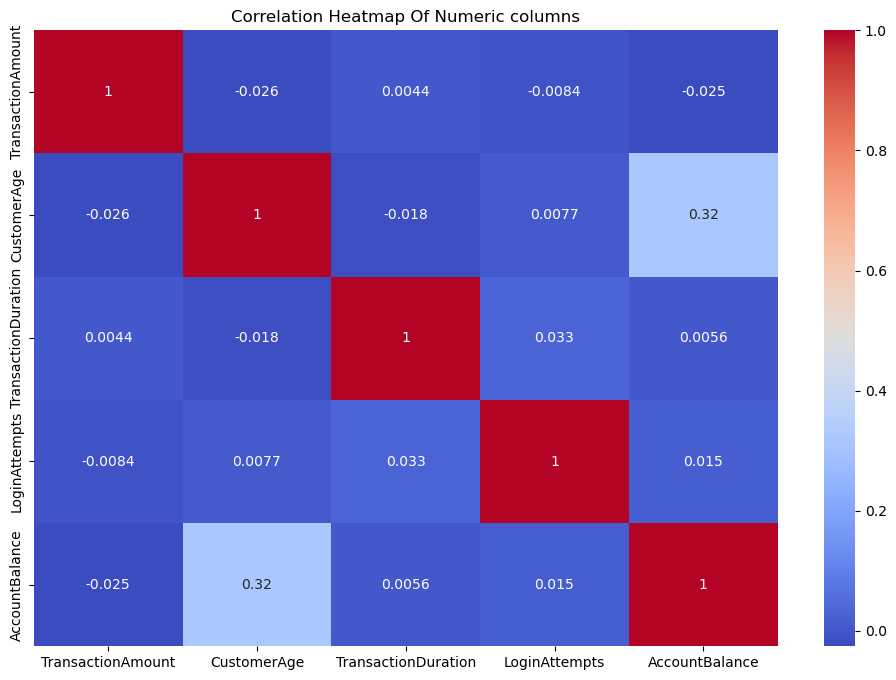

In [13]:
# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap Of Numeric columns")

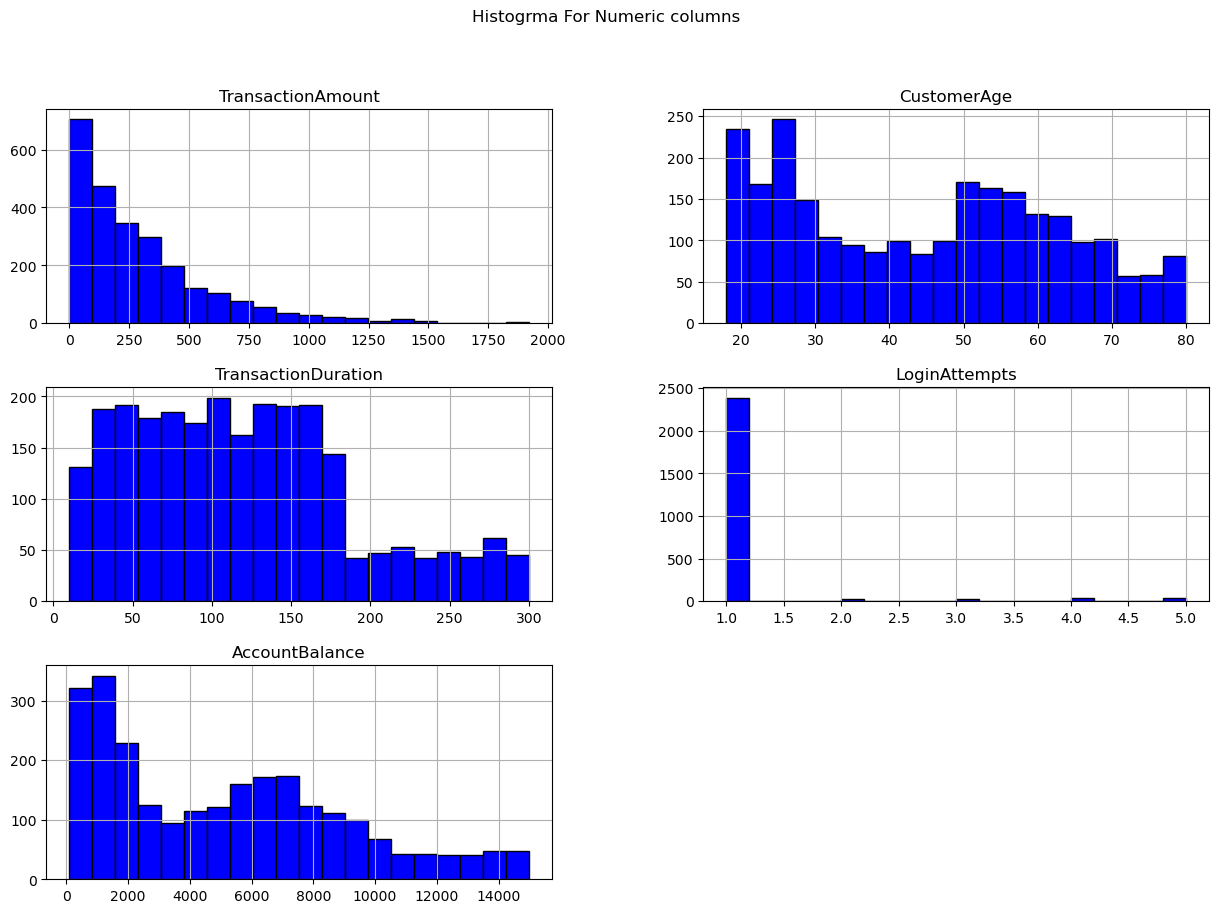

In [20]:
# Histograms for numeric columns 

numeric_data.hist(figsize=(15, 10), bins=20, edgecolor = "black", color= "blue")
plt.suptitle("Histogrma For Numeric columns ")
plt.show()

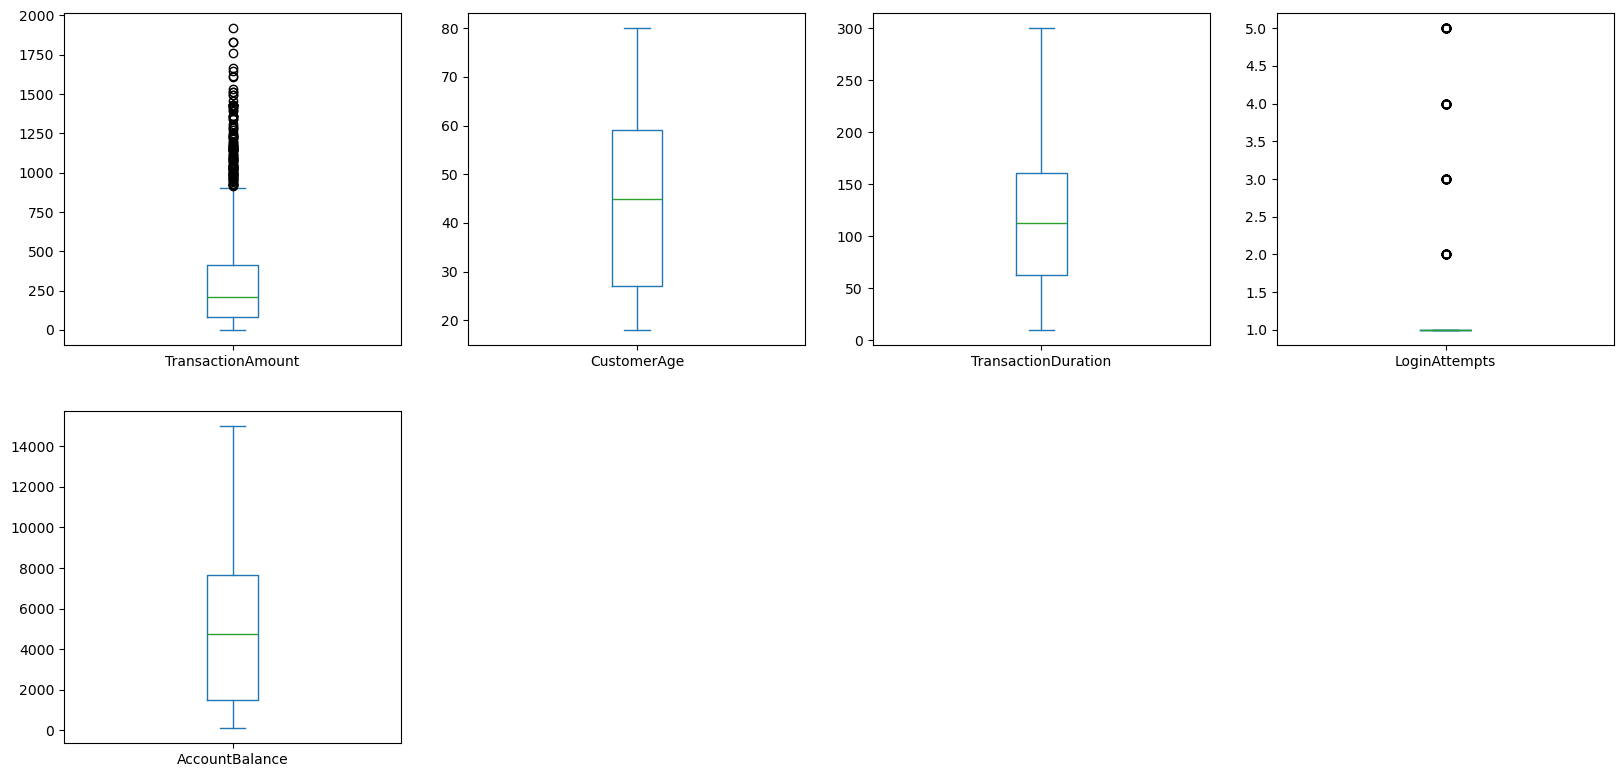

In [23]:
boxPlotAll(df)

In [25]:
# identify numeric and categorical columns 

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
numeric_cols

Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')

In [27]:
categ_cols = df.select_dtypes(include=["object", "category"]). columns
categ_cols

Index(['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType',
       'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel',
       'CustomerOccupation', 'PreviousTransactionDate'],
      dtype='object')

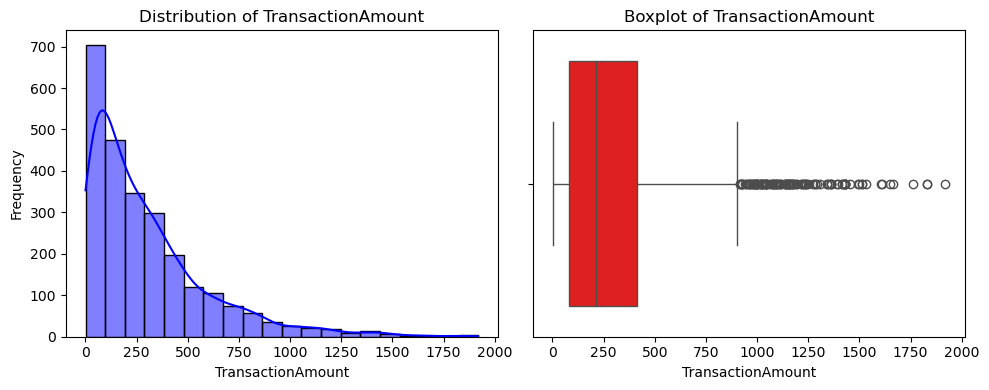

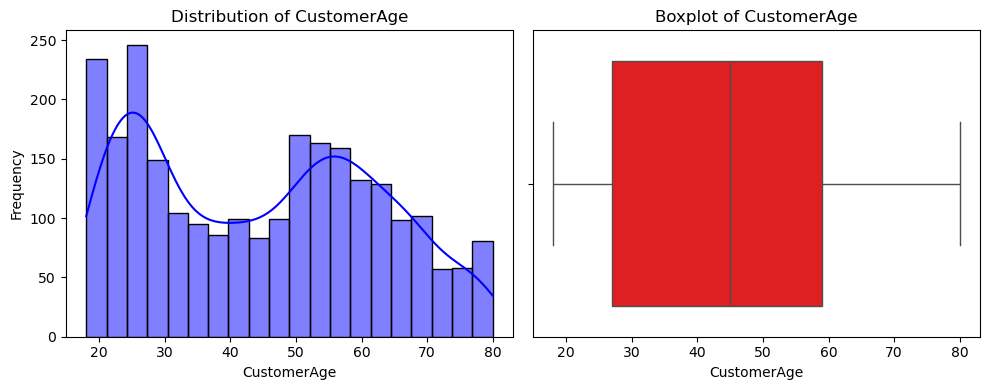

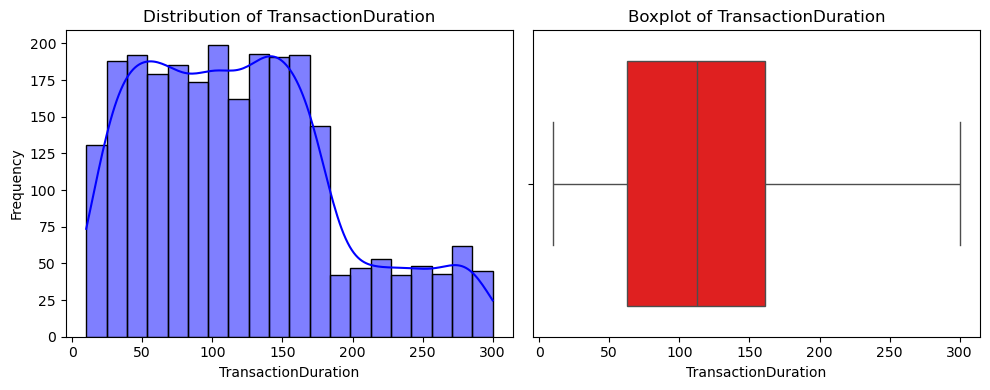

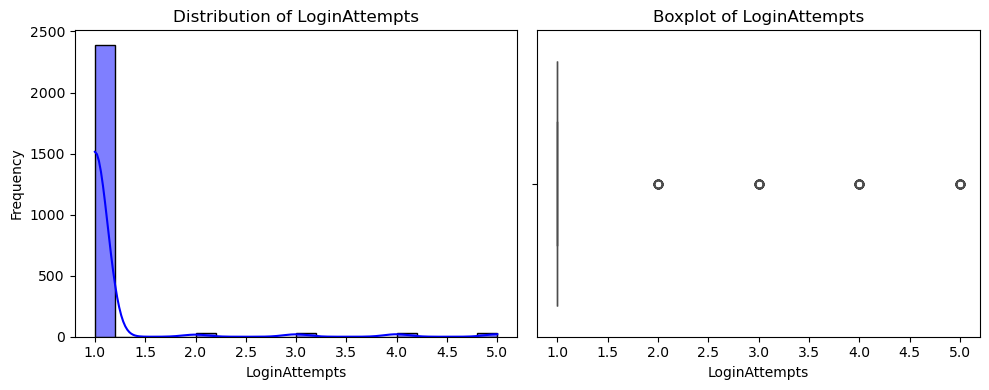

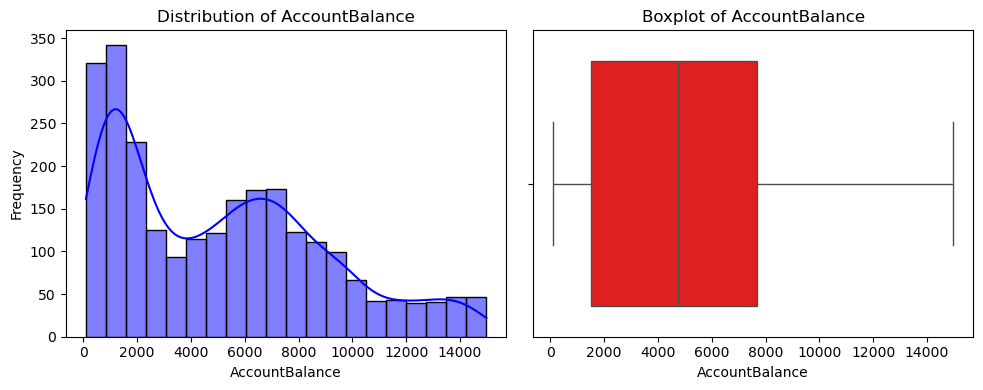

In [28]:
# plot for numeric columns Histograms and box plots

for col in numeric_cols:
    plt.figure(figsize=(10, 4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=20, color="blue", edgecolor= "black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color="red")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\309973656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Location"], order=df["Location"].value_counts().index, palette="viridis")


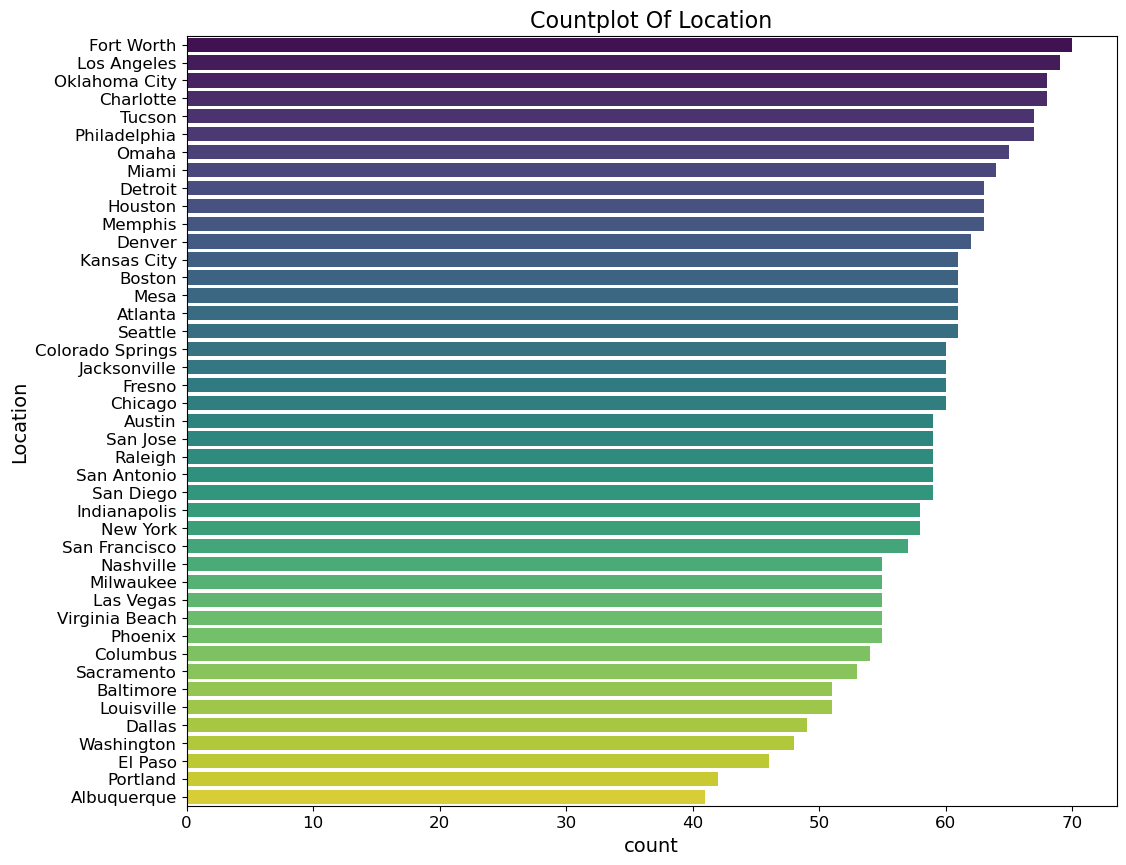

In [34]:
# categorical columns countplots for location
plt.figure(figsize=(12, 10))
sns.countplot(y=df["Location"], order=df["Location"].value_counts().index, palette="viridis")
plt.title("Countplot Of Location", fontsize = 16)
plt.xlabel("count", fontsize = 14)
plt.ylabel("Location", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

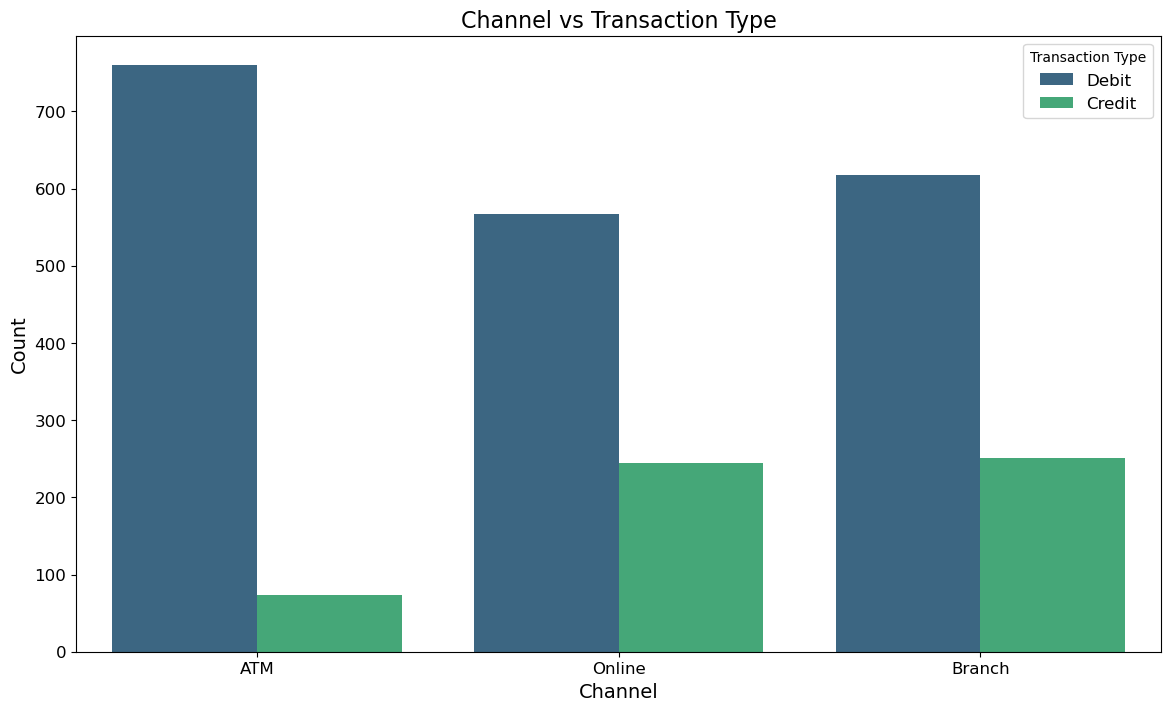

In [37]:
# Bar graph for channel and TranscationType

plt.figure(figsize=(14, 8))
sns.countplot(x="Channel", hue="TransactionType", data = df , palette="viridis")
plt.title("Channel vs Transaction Type", fontsize = 16)
plt.xlabel("Channel", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(title = "Transaction Type", fontsize = 12)
plt.show()

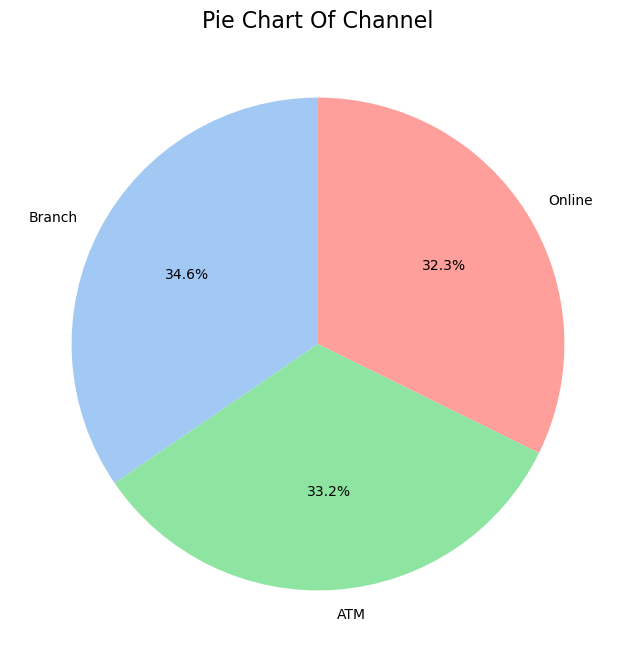

In [40]:
# pie chart for channel

plt.figure(figsize=(8, 8))
df["Channel"].value_counts().plot.pie(autopct= "%1.1f%%", startangle = 90, colors=sns.color_palette("pastel6"))
plt.title("Pie Chart Of Channel", fontsize=16)
plt.ylabel("")  

plt.show()


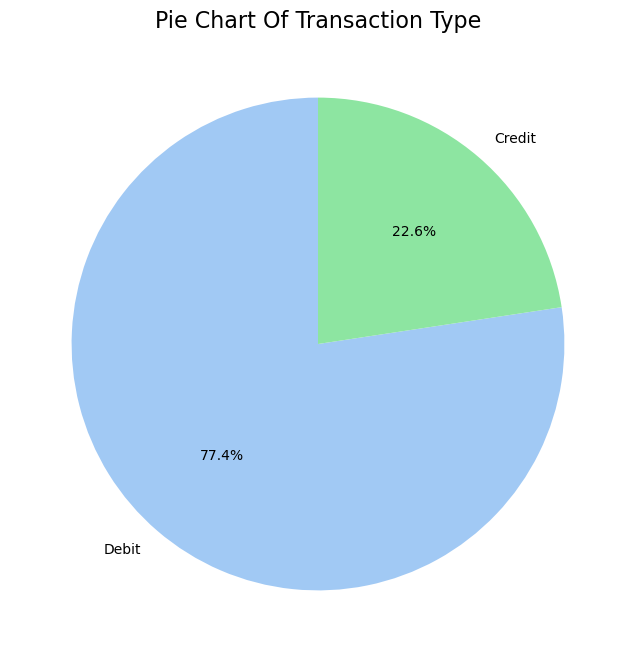

In [41]:
# pie chart for TransactionType

plt.figure(figsize=(8, 8))
df["TransactionType"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel6"))
plt.title("Pie Chart Of Transaction Type", fontsize = 16)
plt.ylabel("")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\2890689303.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="CustomerOccupation", y="CustomerAge", data=df, estimator="mean", palette="muted", ci=None)
C:\Users\HP\AppData\Local\Temp\ipykernel_14488\2890689303.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CustomerOccupation", y="CustomerAge", data=df, estimator="mean", palette="muted", ci=None)


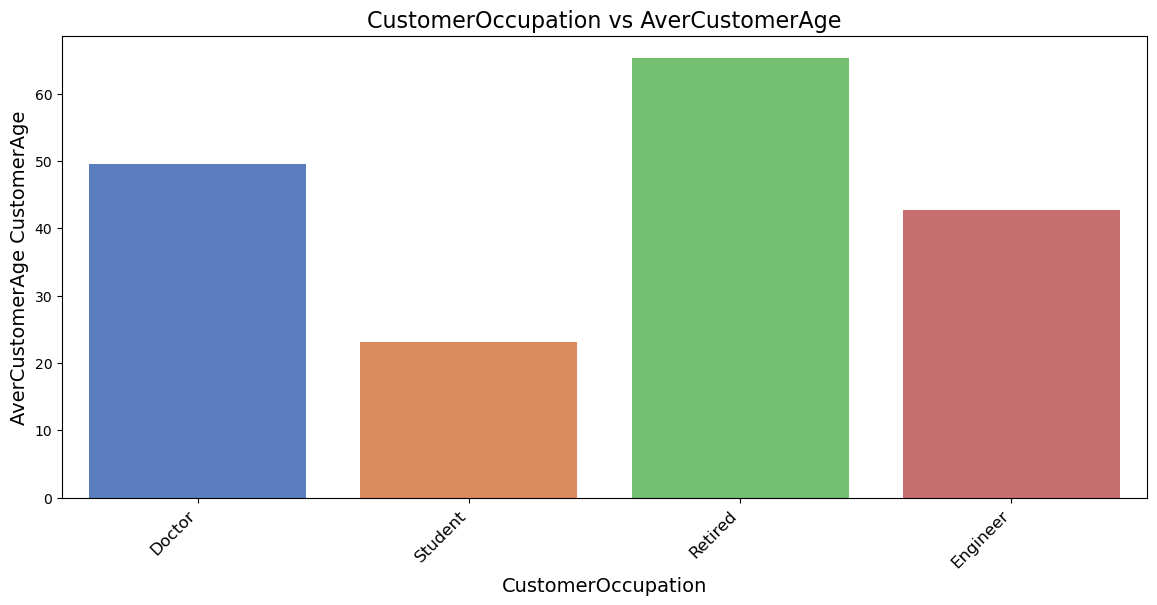

In [42]:
# Bar Chart And Pie Chart For CustomerOccupation With Respect To CustomerAge

plt.figure(figsize=(14, 6))
sns.barplot(x="CustomerOccupation", y="CustomerAge", data=df, estimator="mean", palette="muted", ci=None)
plt.title("CustomerOccupation vs AverCustomerAge", fontsize = 16)
plt.xlabel("CustomerOccupation", fontsize=14)
plt.ylabel("AverCustomerAge CustomerAge", fontsize=14)
plt.xticks(fontsize = 12, rotation=45, ha="right")
plt.show()

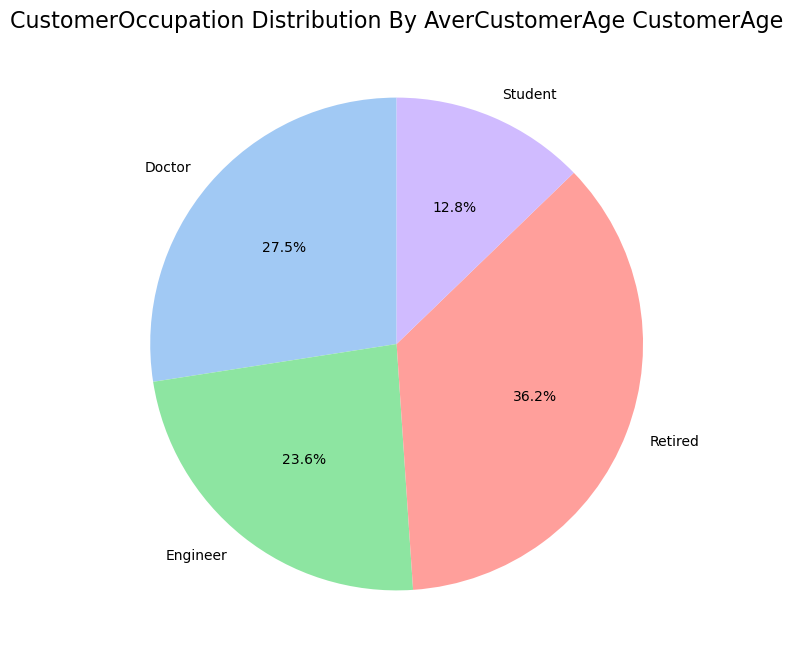

In [43]:
# Pie chart for customerOccupation with respect to customerAge

plt.figure(figsize=(8, 8))
df.groupby("CustomerOccupation")["CustomerAge"].mean().plot.pie(autopct="%1.1f%%", startangle=90, colors = sns.color_palette("pastel6"))
plt.title("CustomerOccupation Distribution By AverCustomerAge CustomerAge", fontsize=16)
plt.ylabel("")
plt.show()

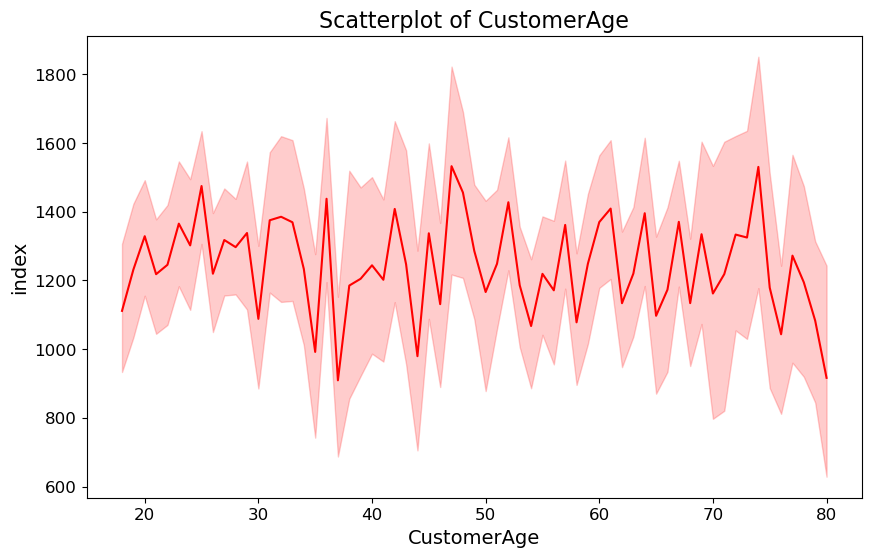

In [44]:
# scatterplot for customerAge

plt.figure(figsize=(10, 6))
sns.lineplot(y=df.index, x=df["CustomerAge"], color = "red")
plt.title("Scatterplot of CustomerAge", fontsize = 16)
plt.ylabel("index", fontsize=14)
plt.xlabel("CustomerAge", fontsize = 14)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\3193004835.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[df["MerchantID"].isin(top_10_merchants)]["MerchantID"], order=top_10_merchants, palette="coolwarm")


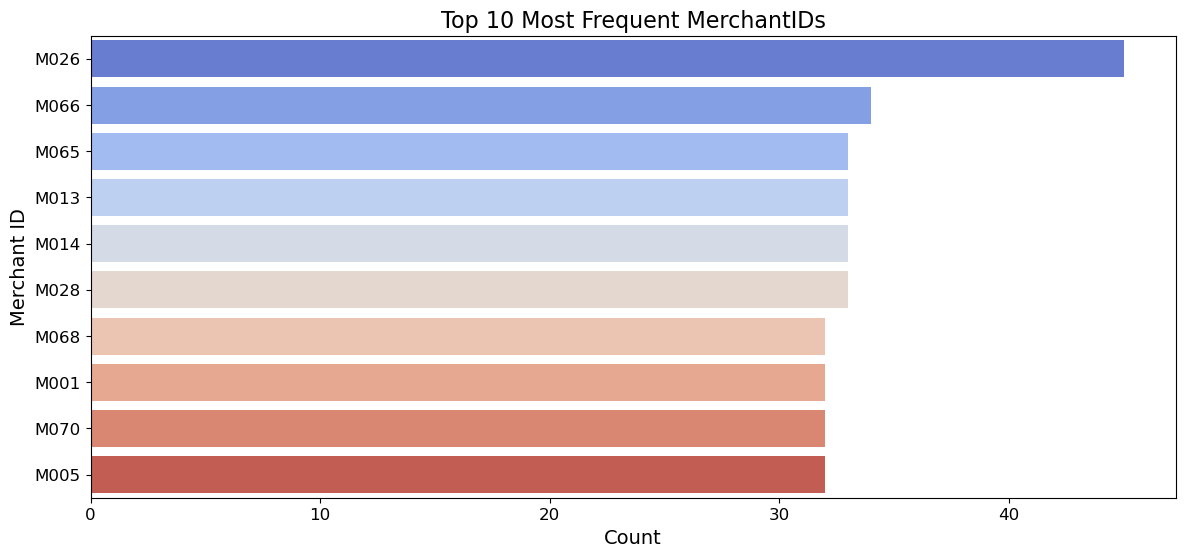

In [46]:
# countplot for top 10 merchatID 
top_10_merchants = df["MerchantID"].value_counts().head(10).index
plt.figure(figsize=(14, 6))
sns.countplot(y=df[df["MerchantID"].isin(top_10_merchants)]["MerchantID"], order=top_10_merchants, palette="coolwarm")
plt.title("Top 10 Most Frequent MerchantIDs", fontsize = 16)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Merchant ID", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_14488\3448180124.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[df["AccountID"].isin(top_10_accountID)]["AccountID"], order=top_10_accountID, palette="coolwarm")


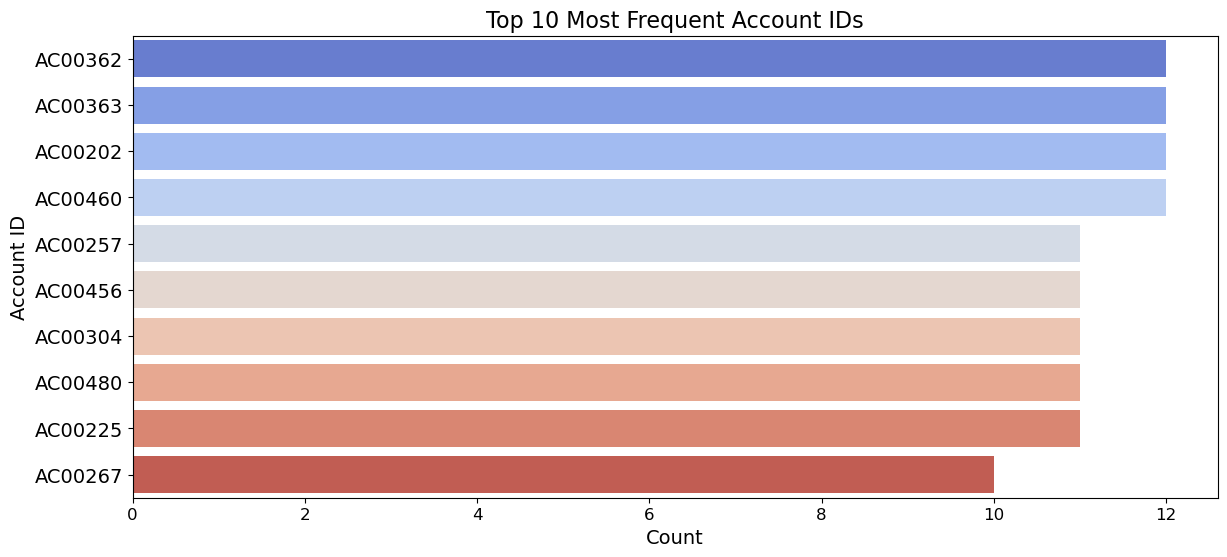

In [47]:
# Countplot for top 10 most frequent AccountID
top_10_accountID = df["AccountID"].value_counts().head(10).index
plt.figure(figsize=(14, 6))
sns.countplot(y=df[df["AccountID"].isin(top_10_accountID)]["AccountID"], order=top_10_accountID, palette="coolwarm")
plt.title("Top 10 Most Frequent Account IDs", fontsize=16)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Account ID", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.show()

Bivariate Analysis

In [48]:
# Bivariate analysis examines the relationship between two variables

In [49]:
# Define numeric and categorical columns

numeric_cols = ["TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance"]

categ_cols = ["TransactionType", "Location", "Channel", "CustomerOccupation"]

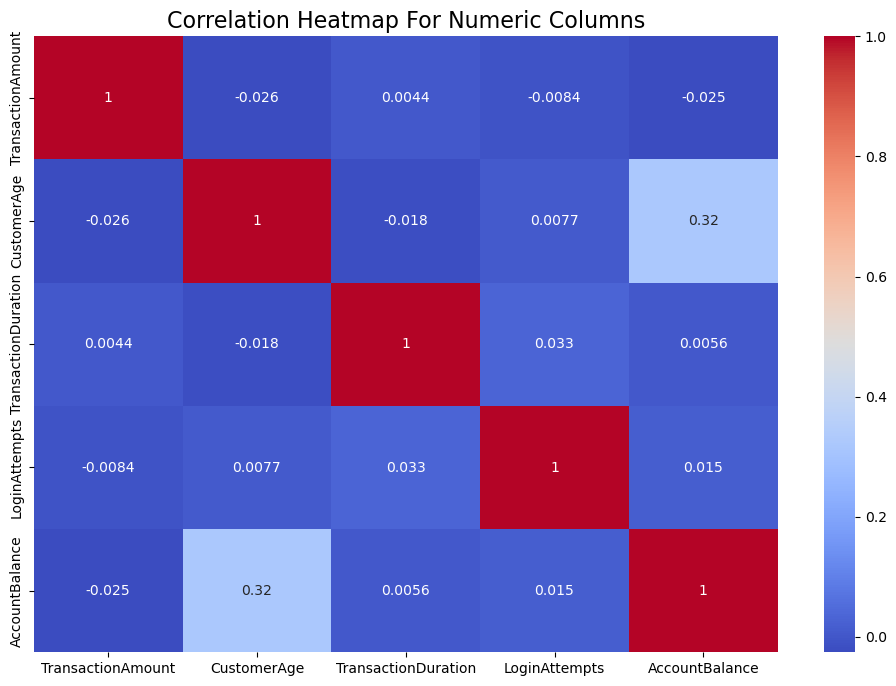

In [50]:
# correlation Heatmap for Numeric Columns

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap For Numeric Columns", fontsize=16)
plt.show()

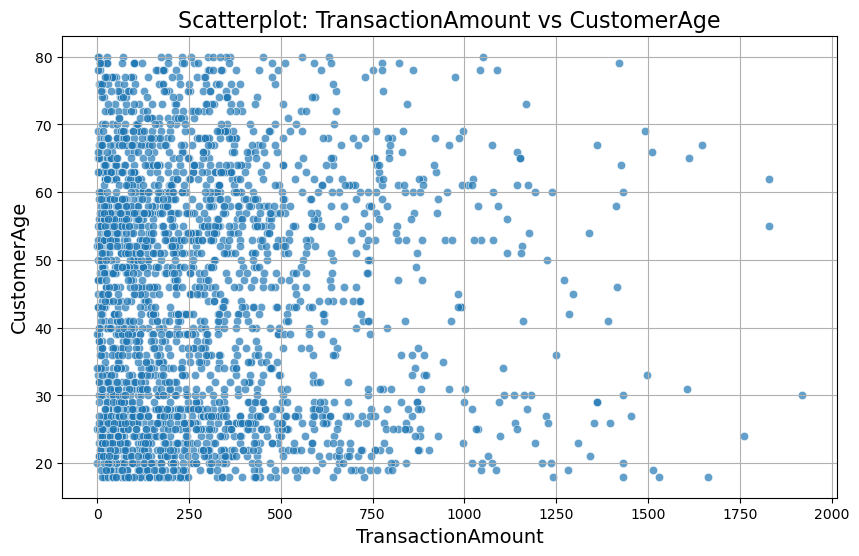

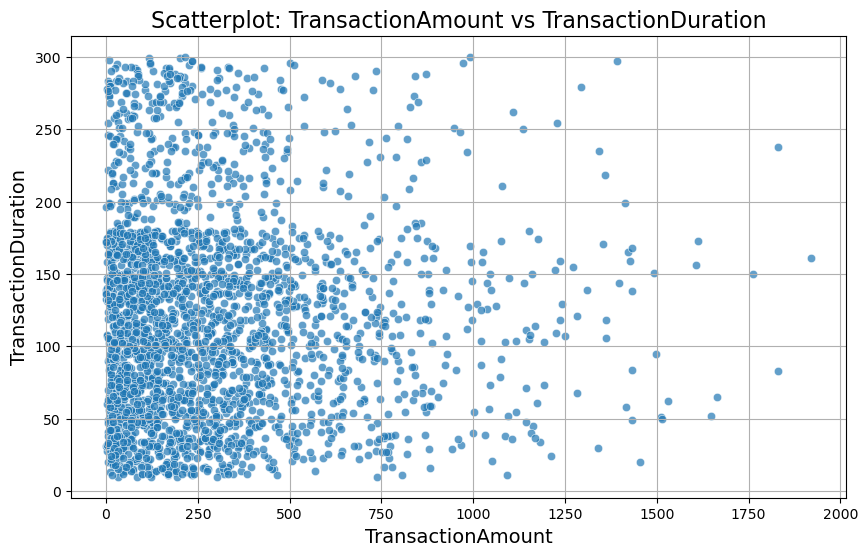

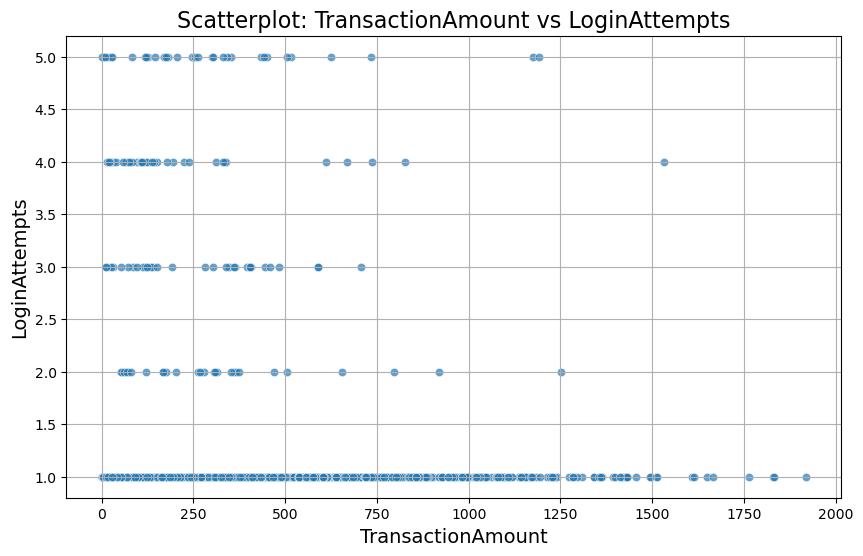

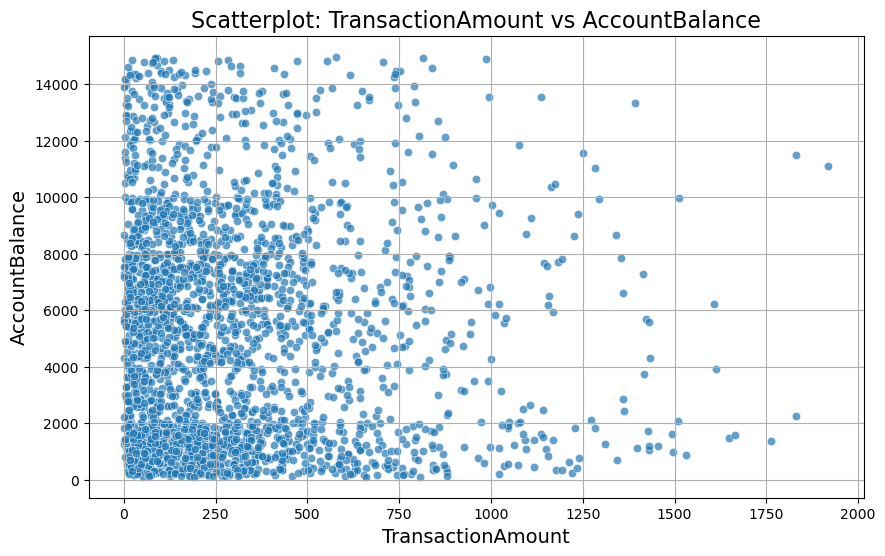

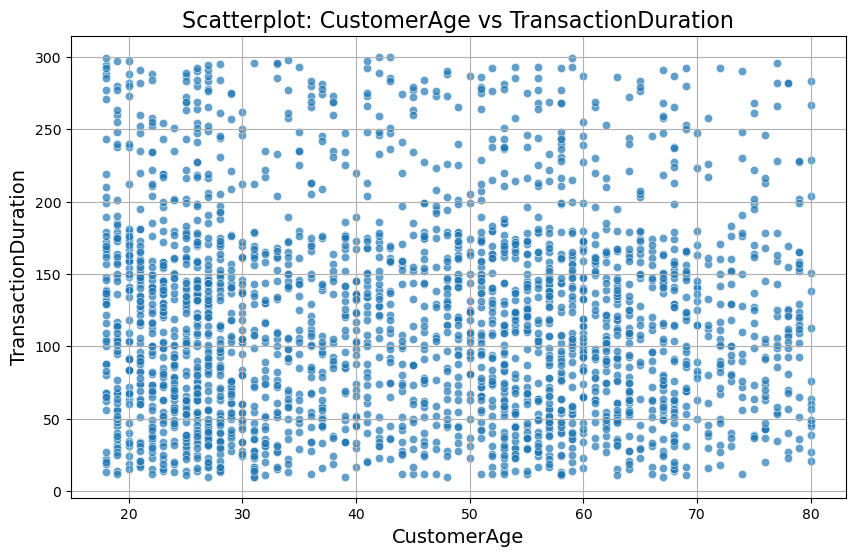

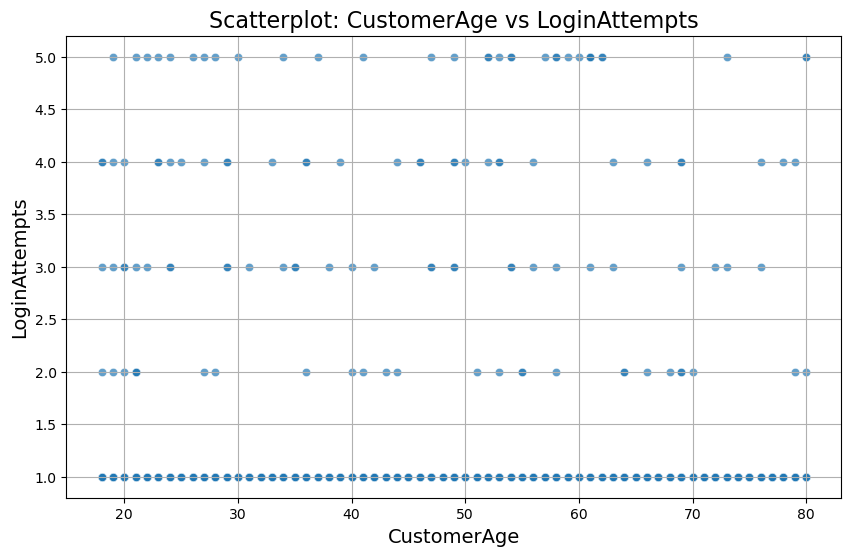

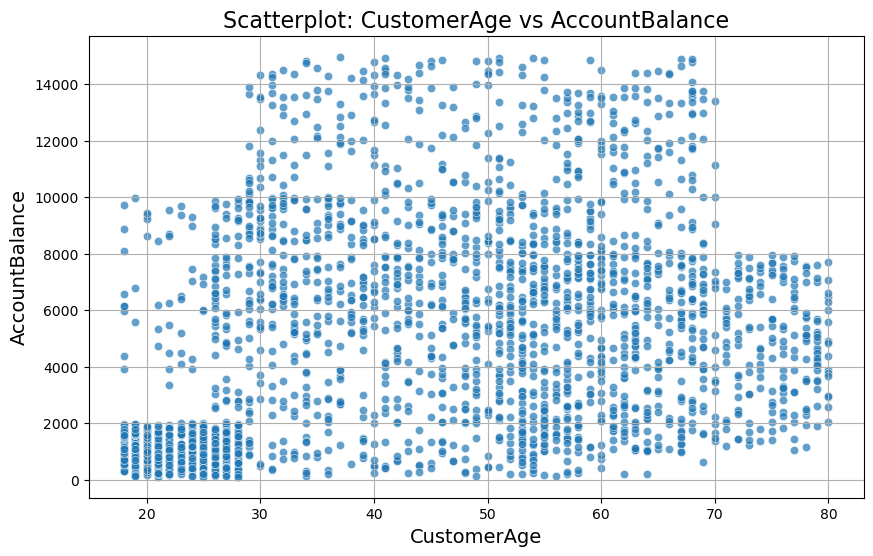

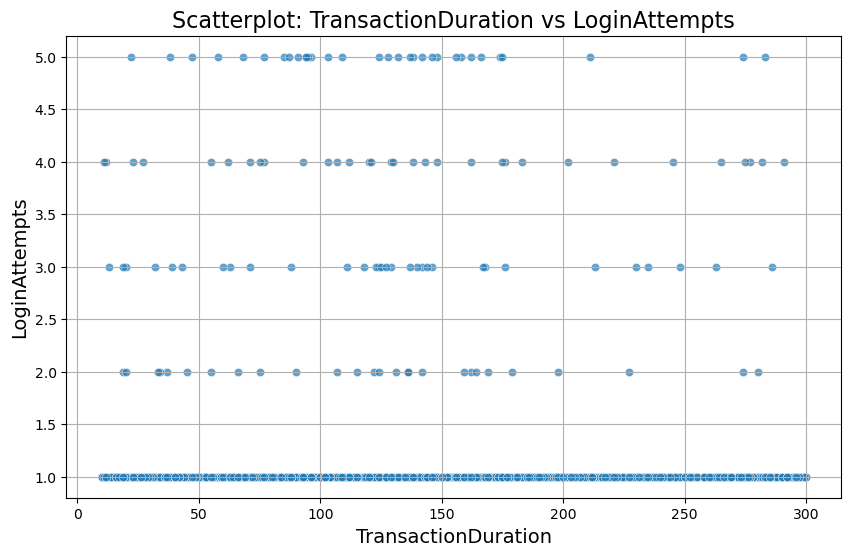

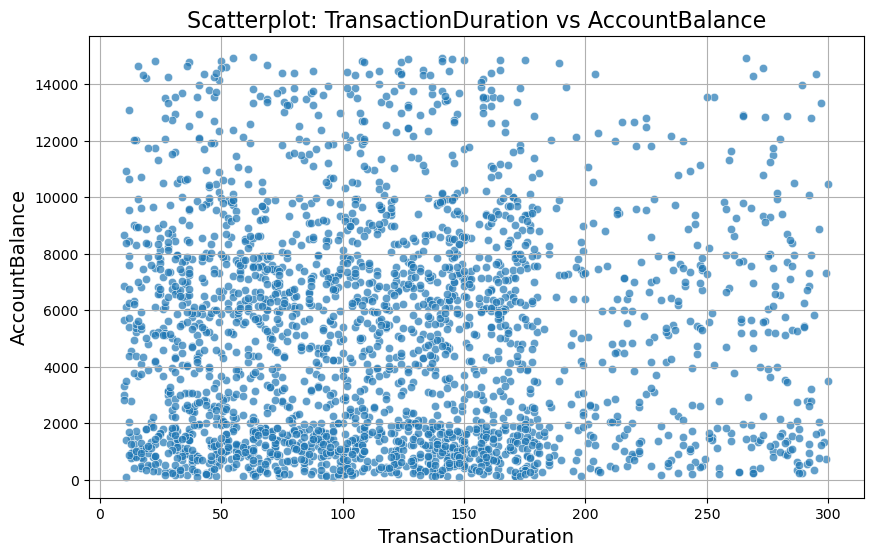

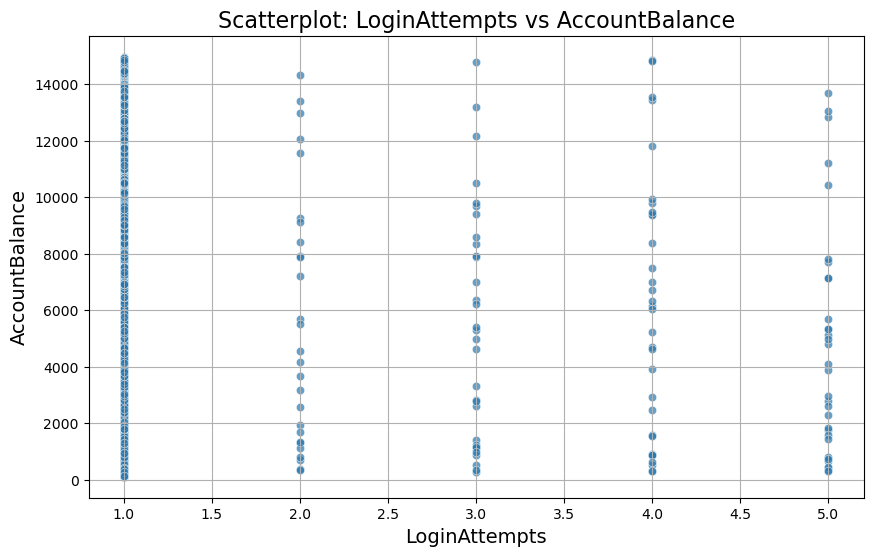

In [51]:
# Scatterplot for numeric vs numeric 
for i, col1 in enumerate(numeric_cols):
    for col2 in numeric_cols[i+1:]:
        plt.figure(figsize=(10,6))
        sns.scatterplot(x=df[col1], y=df[col2], alpha= 0.7)
        plt.title(f"Scatterplot: {col1} vs {col2}", fontsize=16)
        plt.xlabel(col1, fontsize=14)
        plt.ylabel(col2, fontsize=14)
        plt.grid(True)
        plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


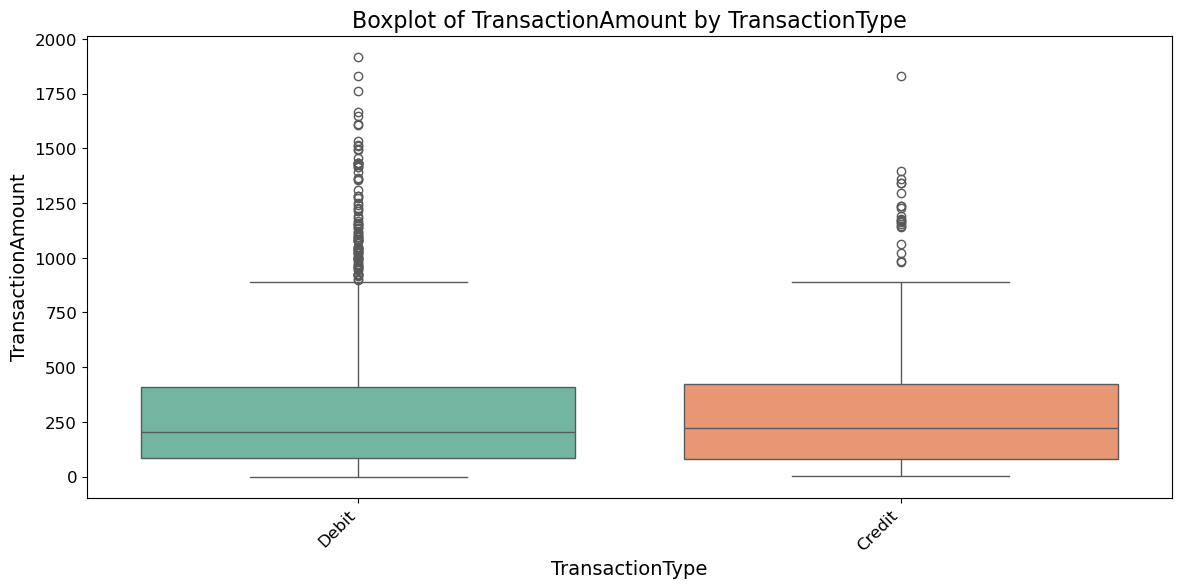

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


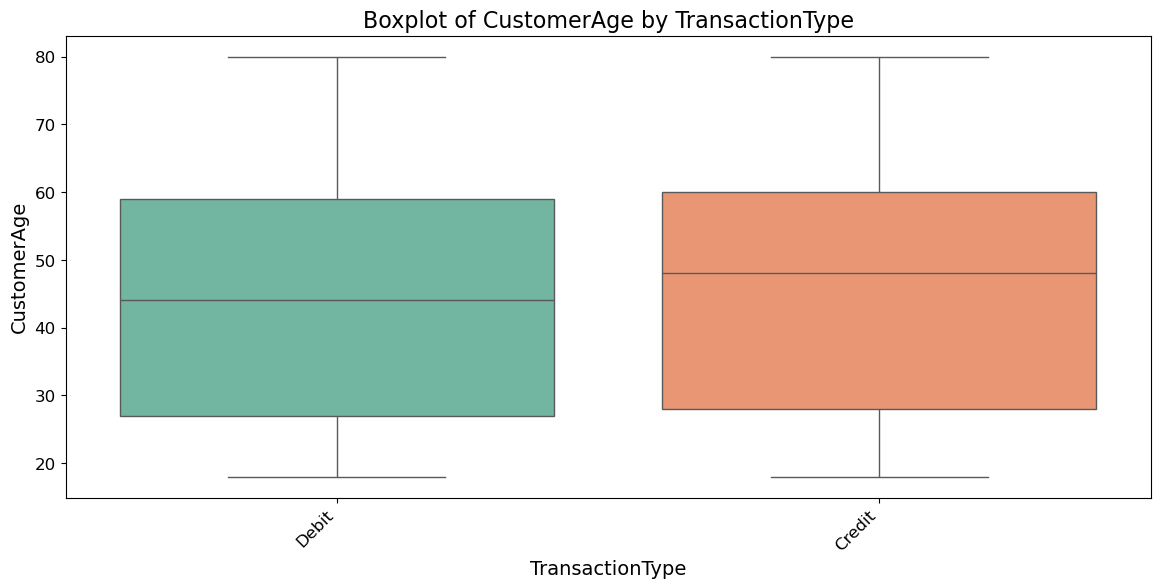

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


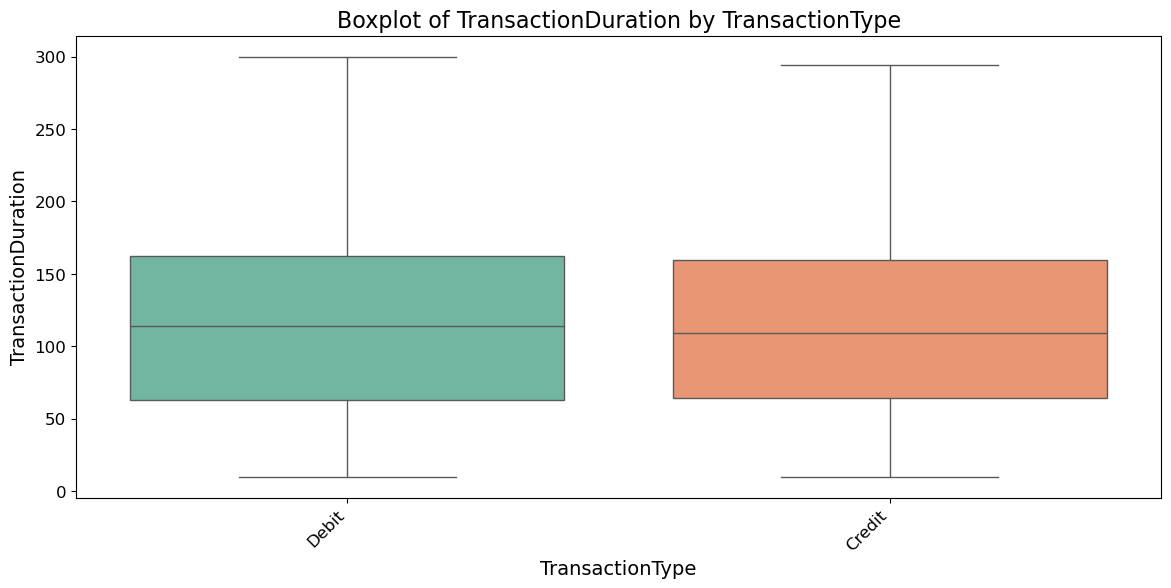

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


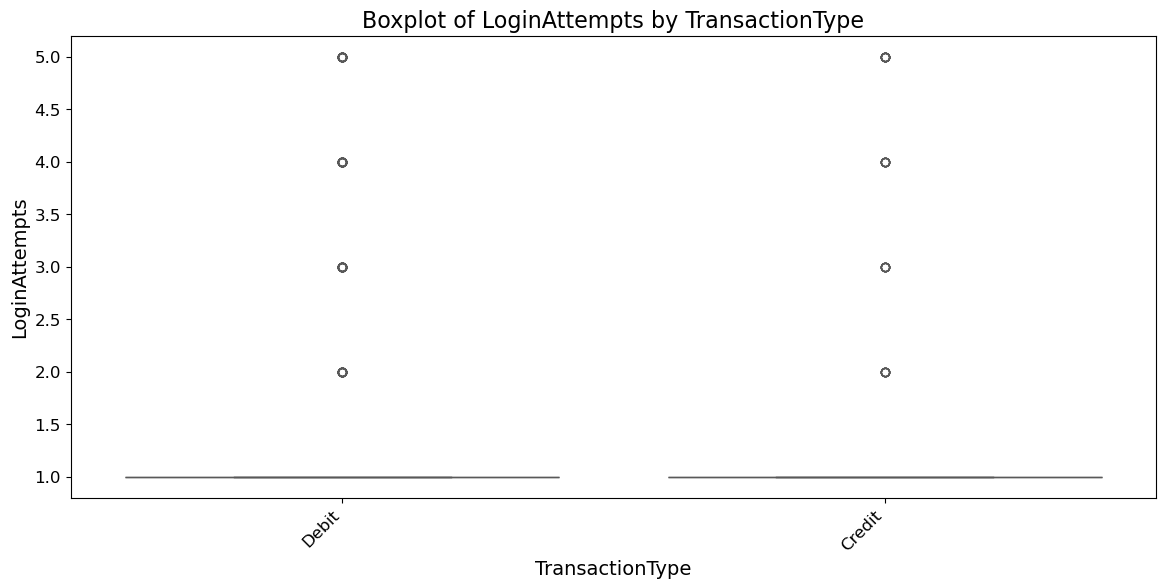

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


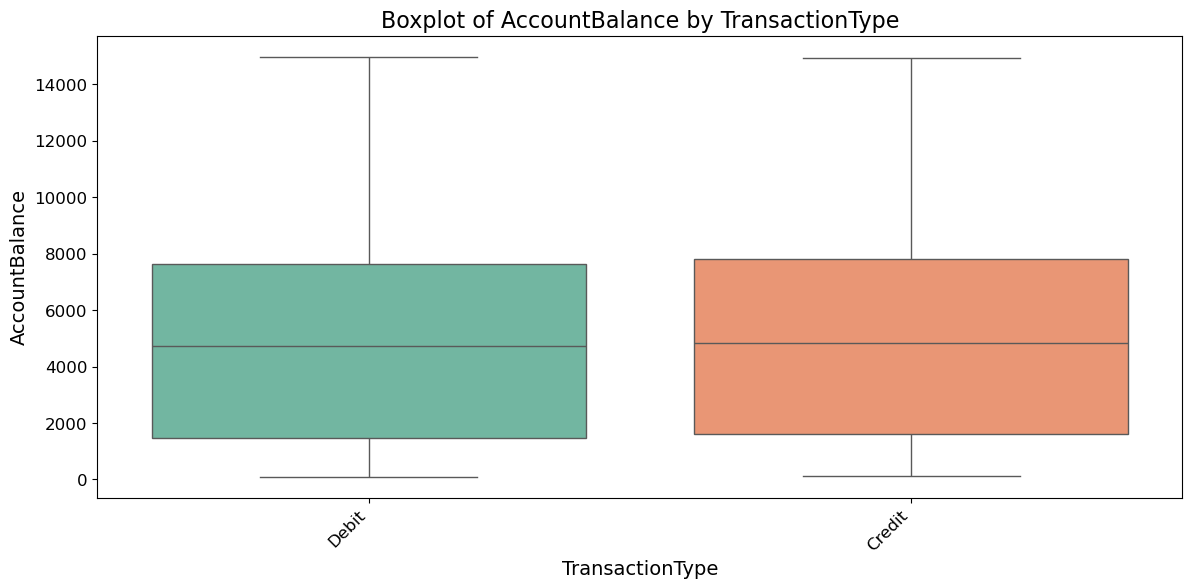

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


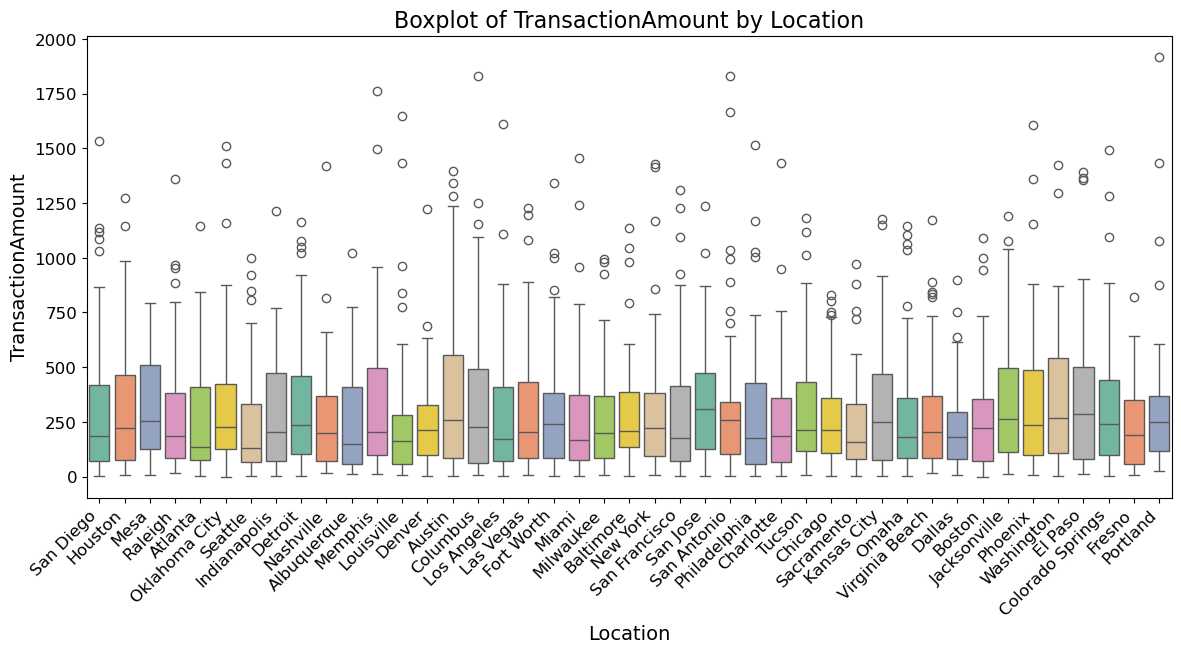

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


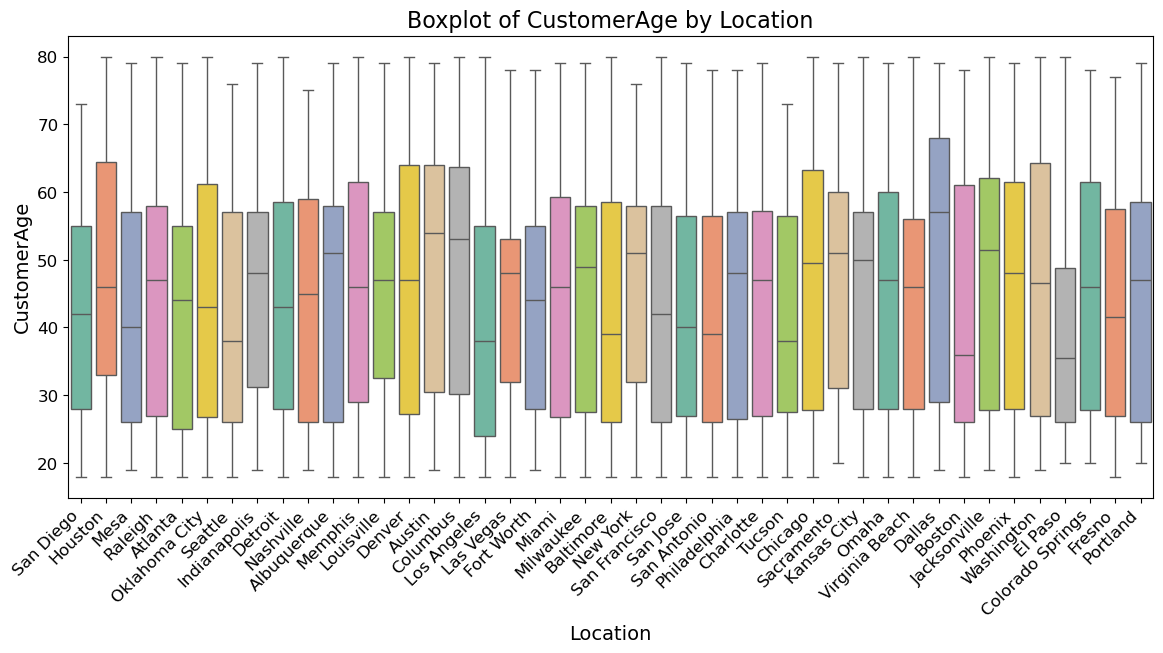

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


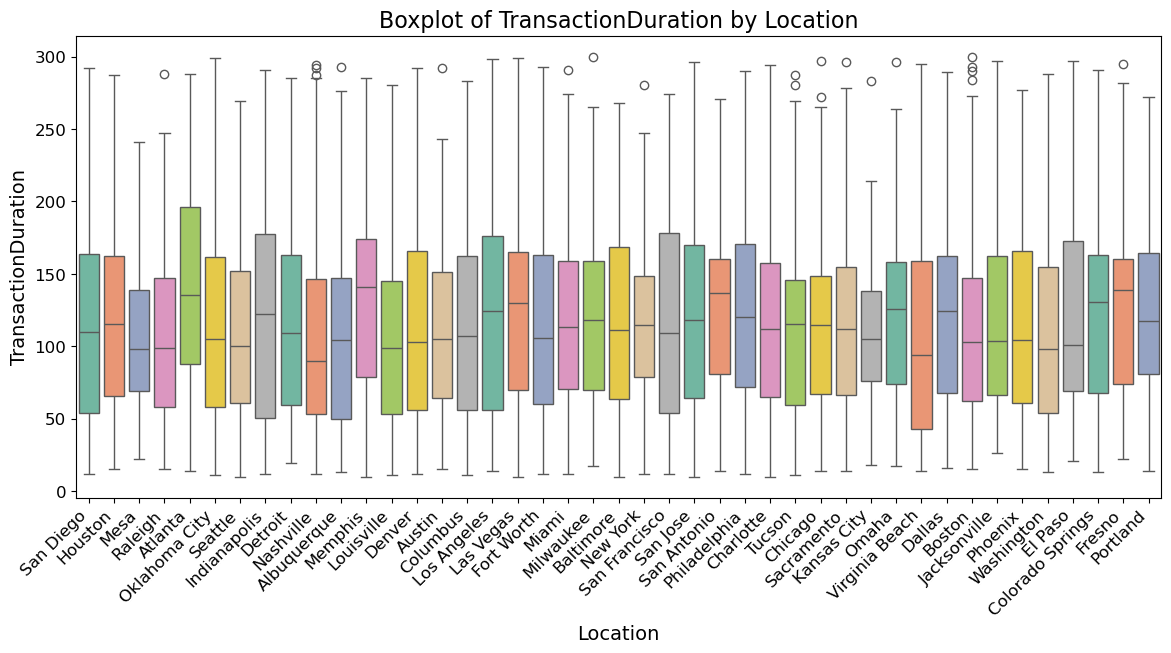

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


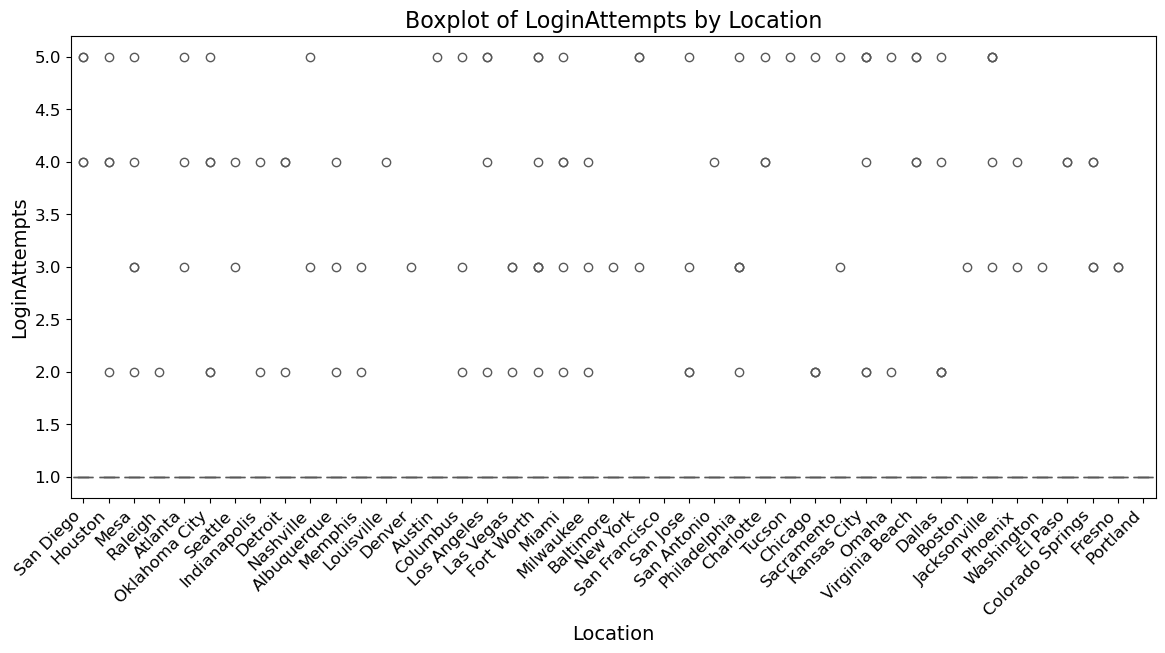

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


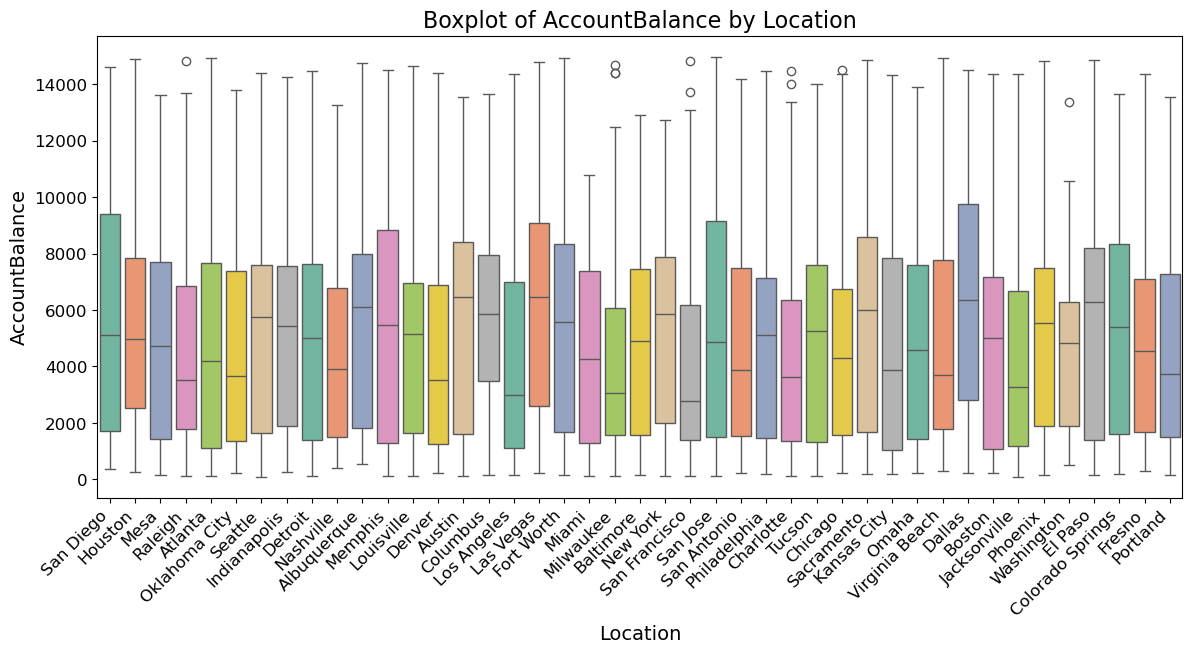

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


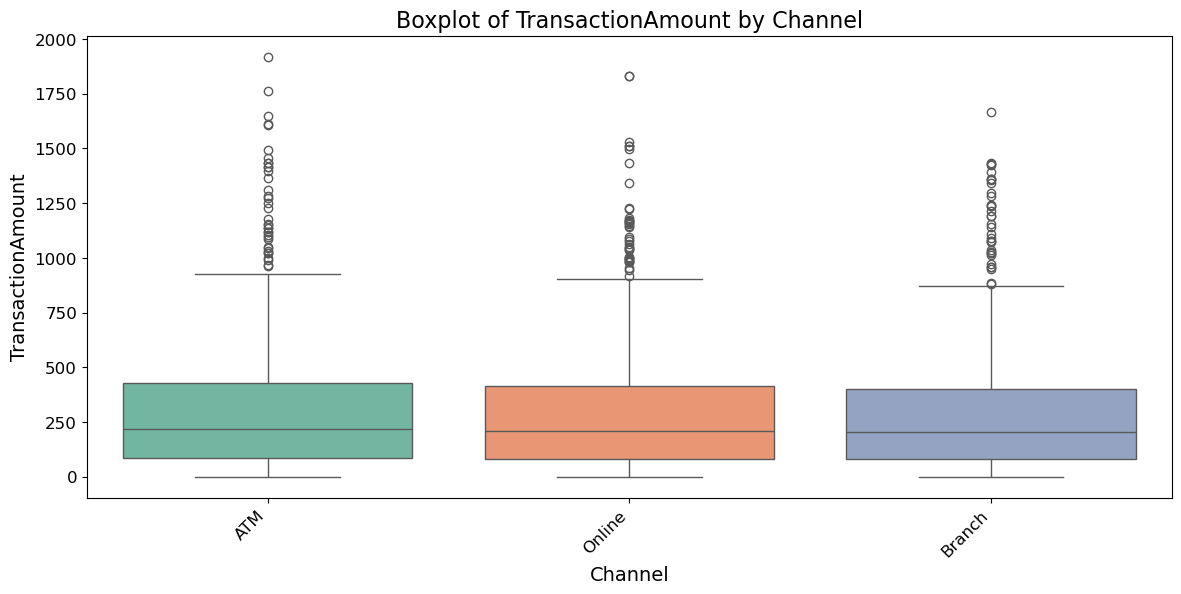

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


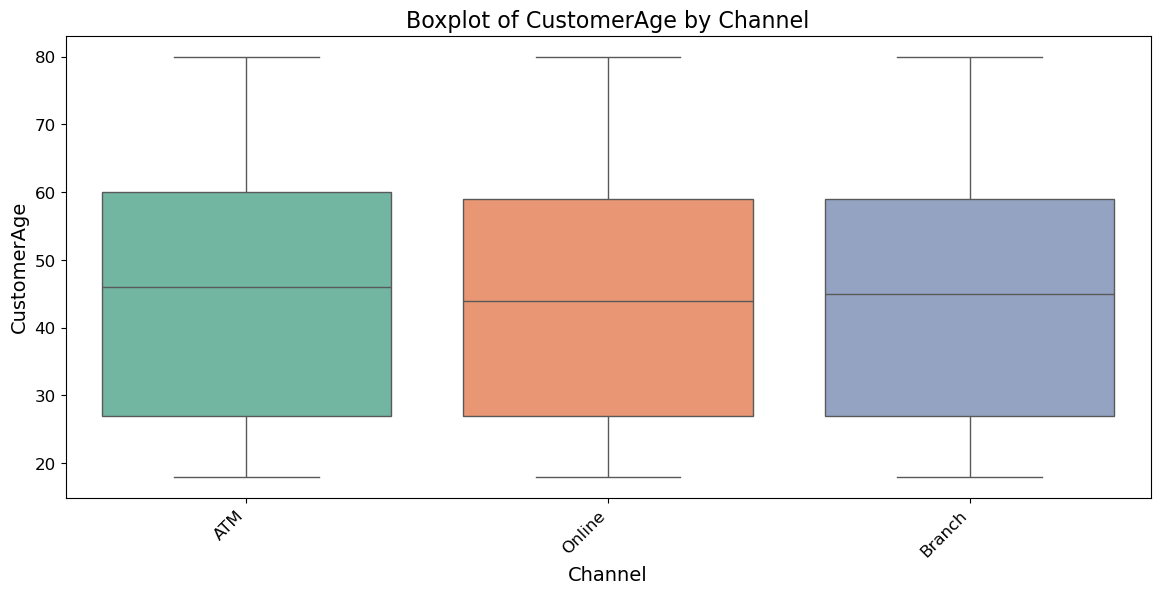

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


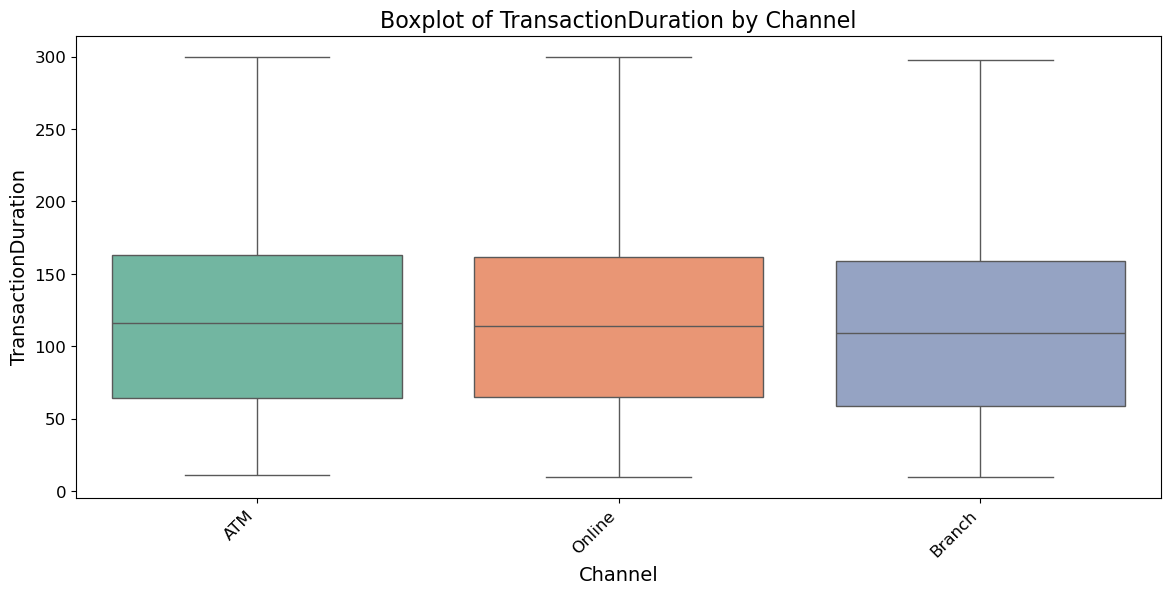

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


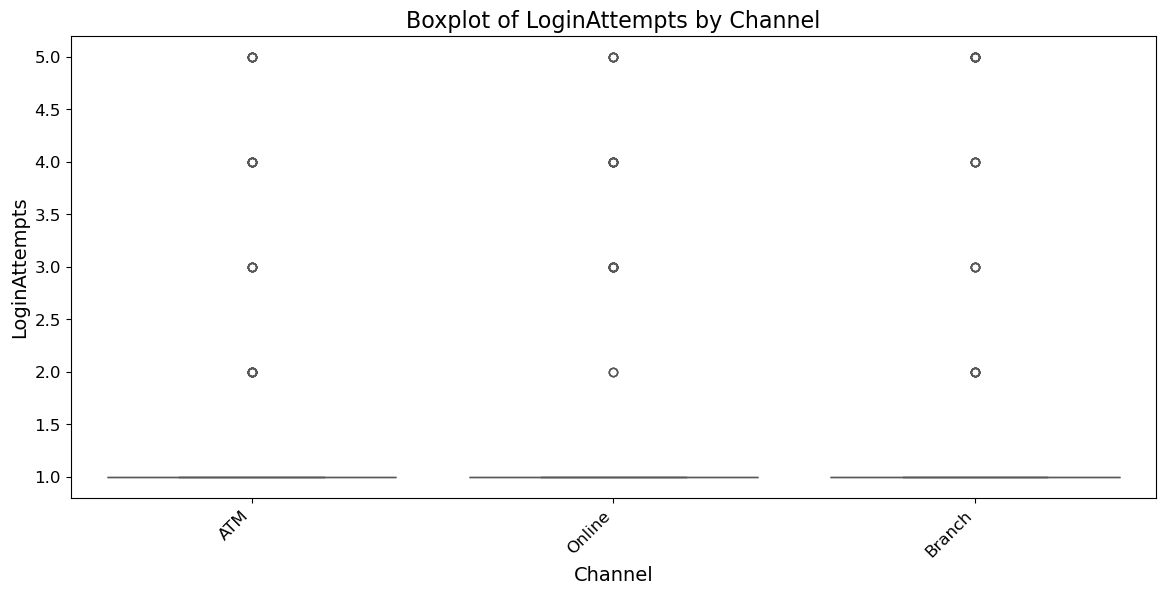

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


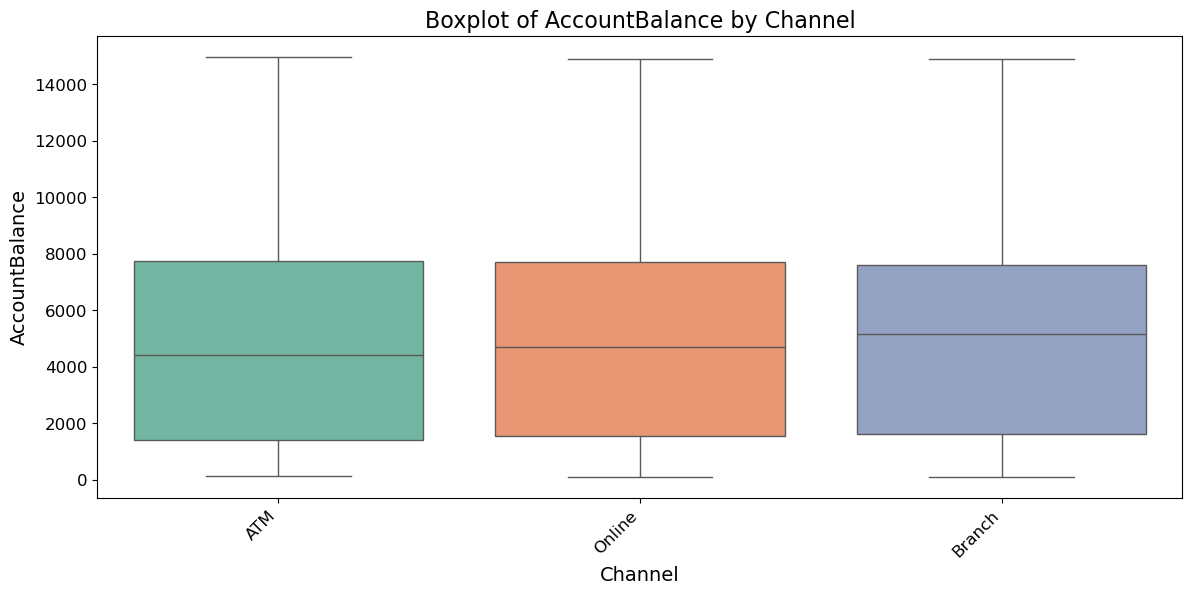

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


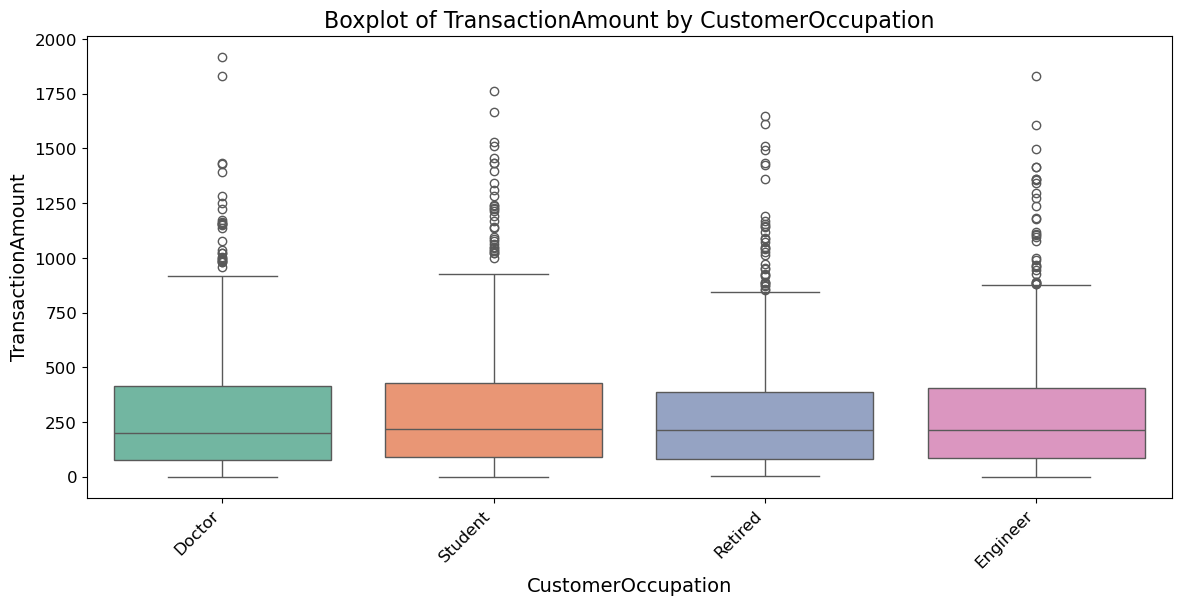

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


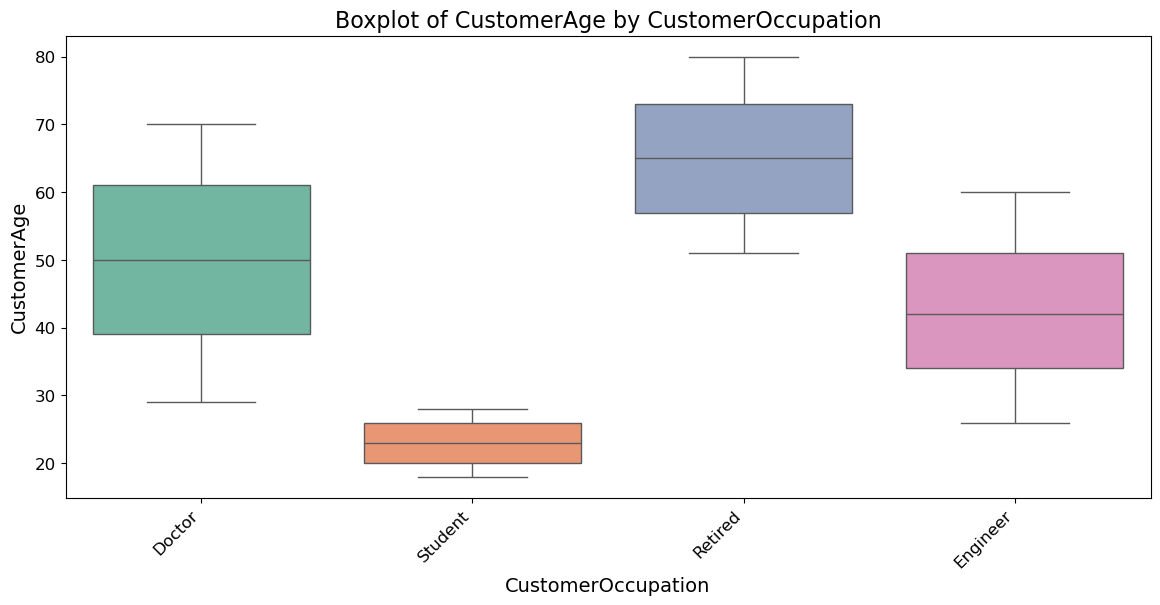

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


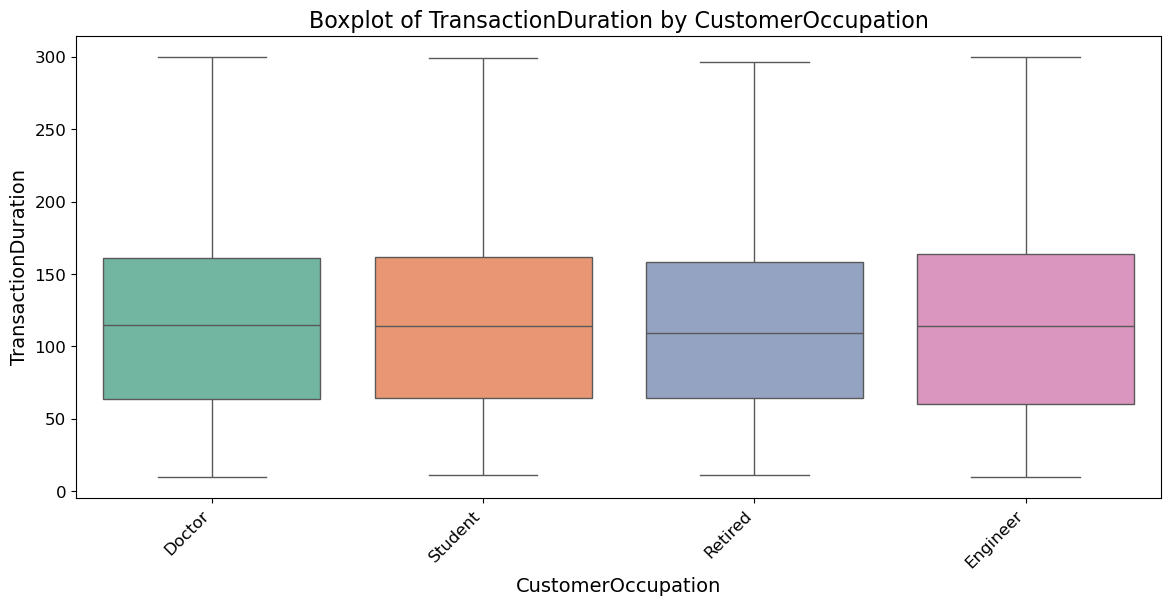

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


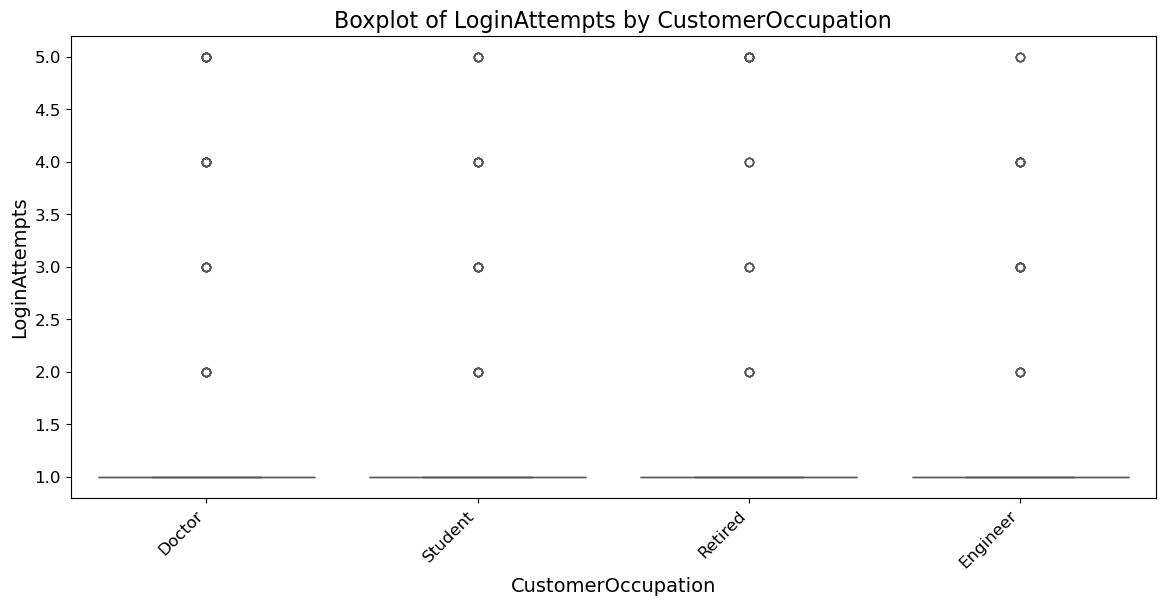

C:\Users\HP\AppData\Local\Temp\ipykernel_14488\714706752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")


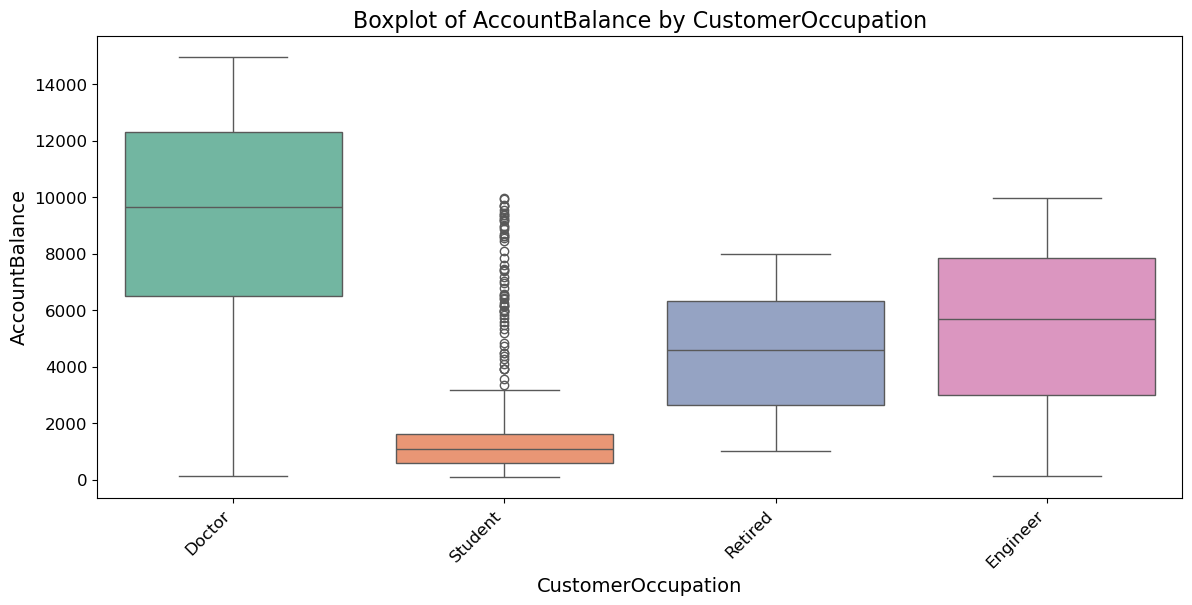

In [54]:
# Boxplot for numeric vs categorical

for categ_col in categ_cols:
    for numeric_col in numeric_cols:
        plt.figure(figsize=(14, 6))
        sns.boxplot(x=categ_col, y=numeric_col,data=df, palette="Set2")
        plt.title(f"Boxplot of {numeric_col} by {categ_col}", fontsize=16)
        plt.xlabel(categ_col, fontsize=14)
        plt.ylabel(numeric_col, fontsize=14)
        plt.xticks(rotation=45, fontsize=12, ha="right")
        plt.yticks(fontsize=12)
        plt.show()

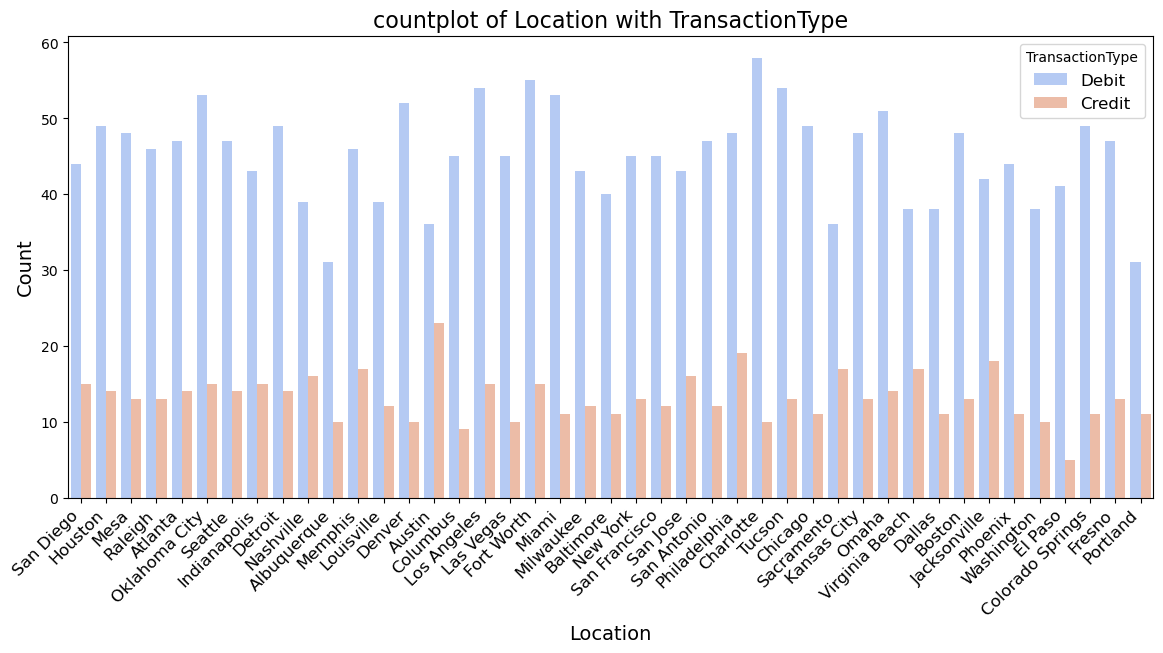

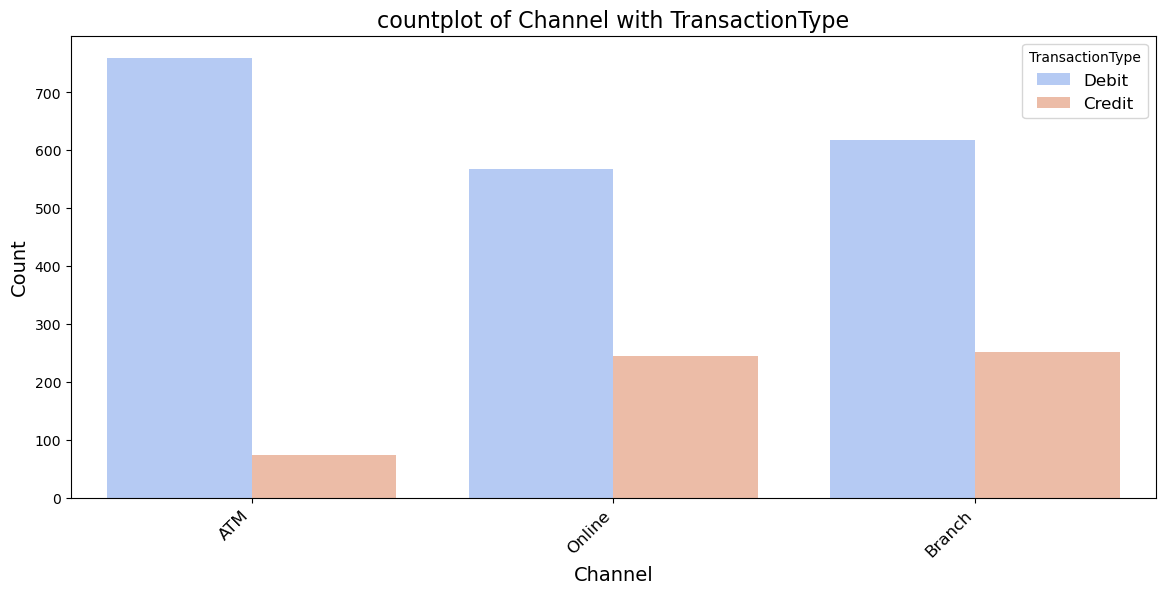

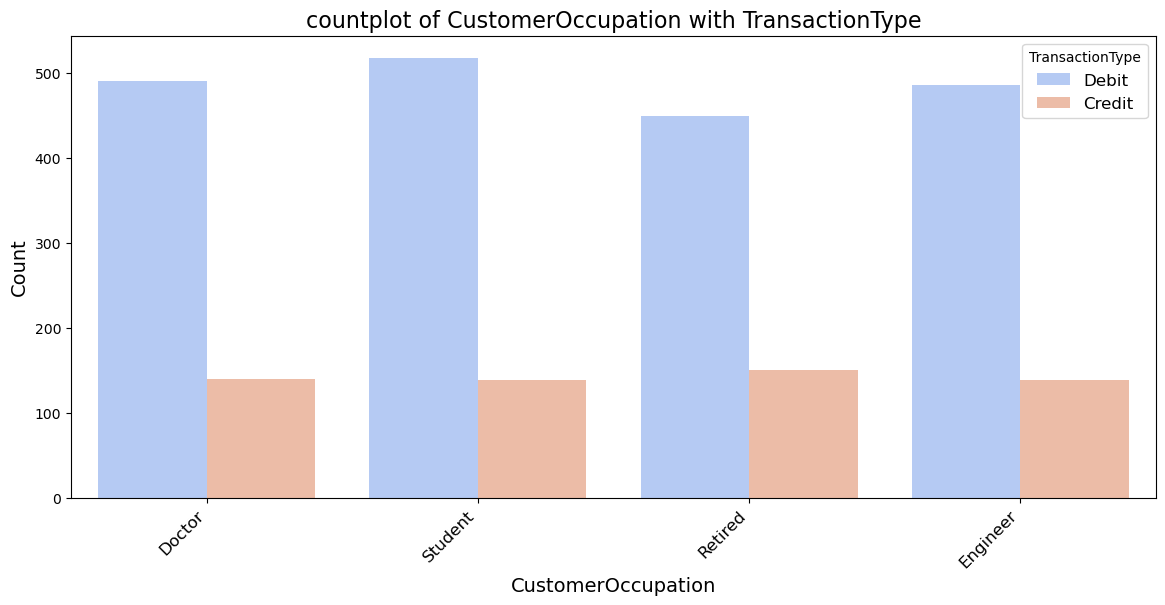

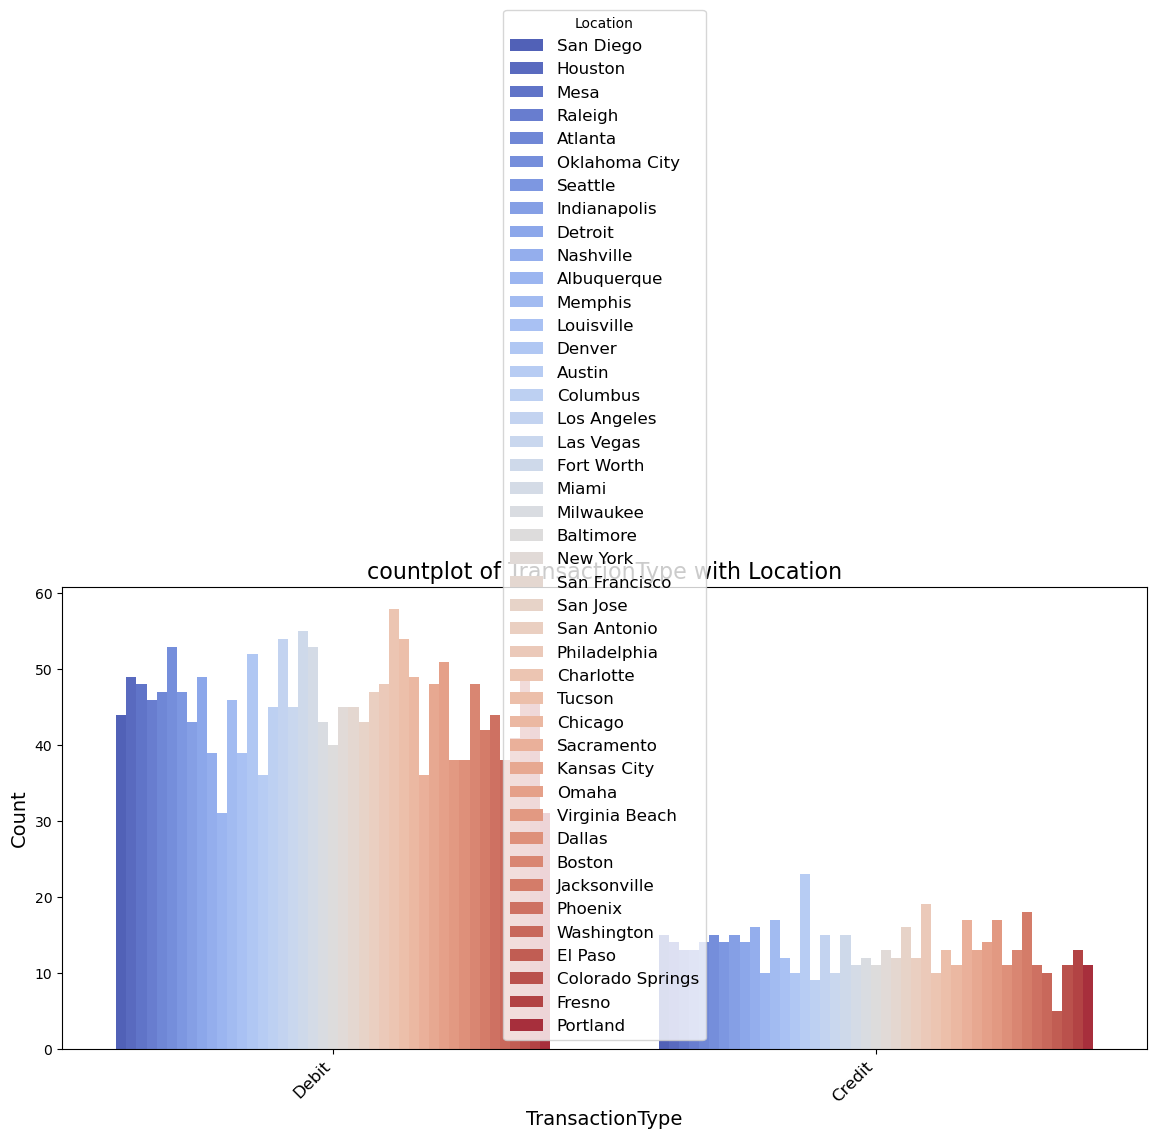

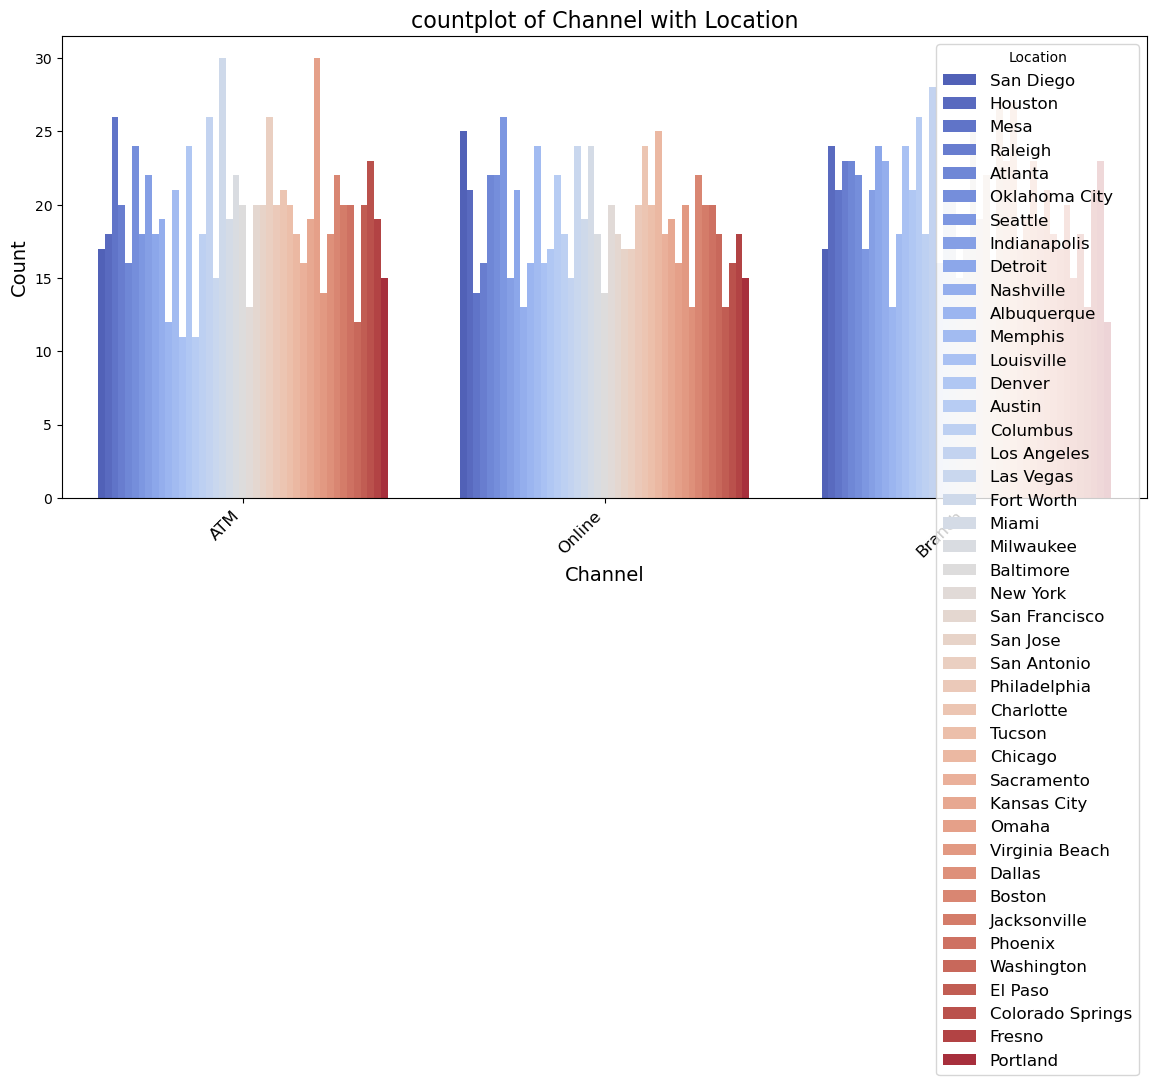

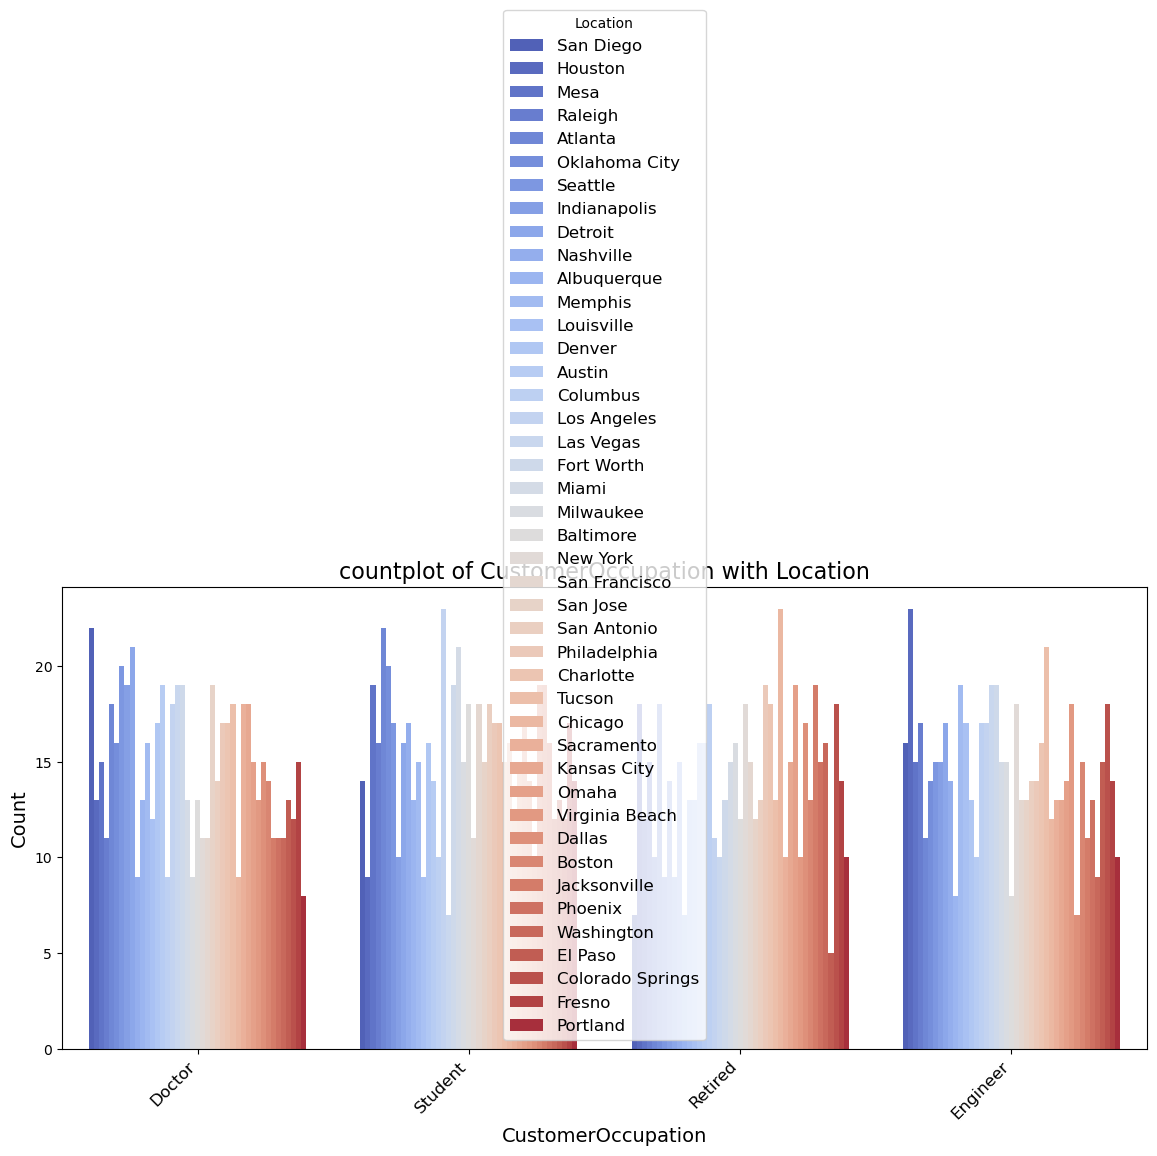

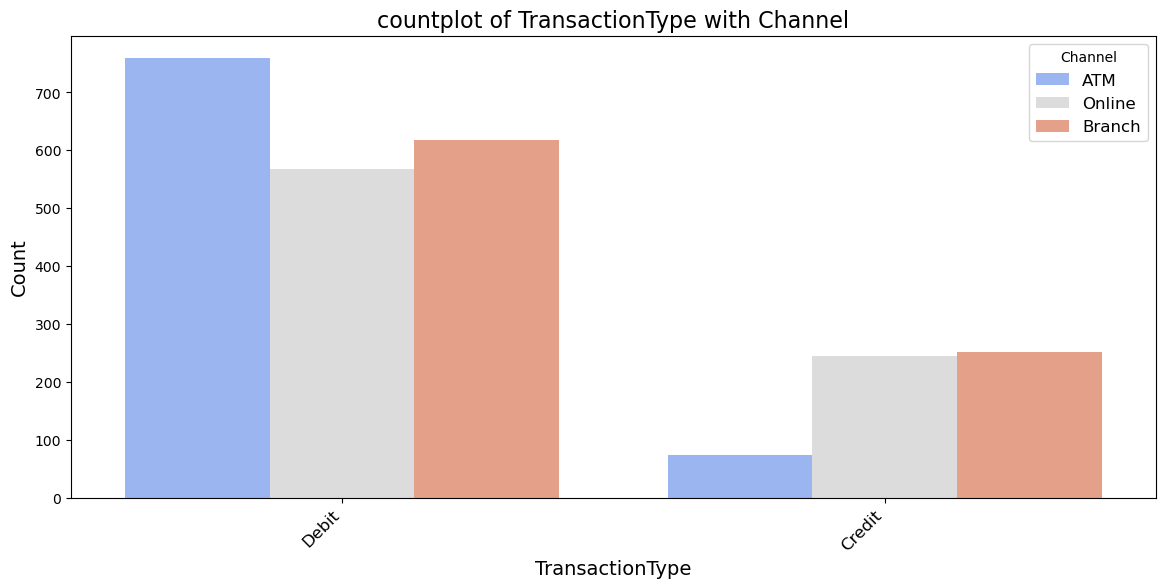

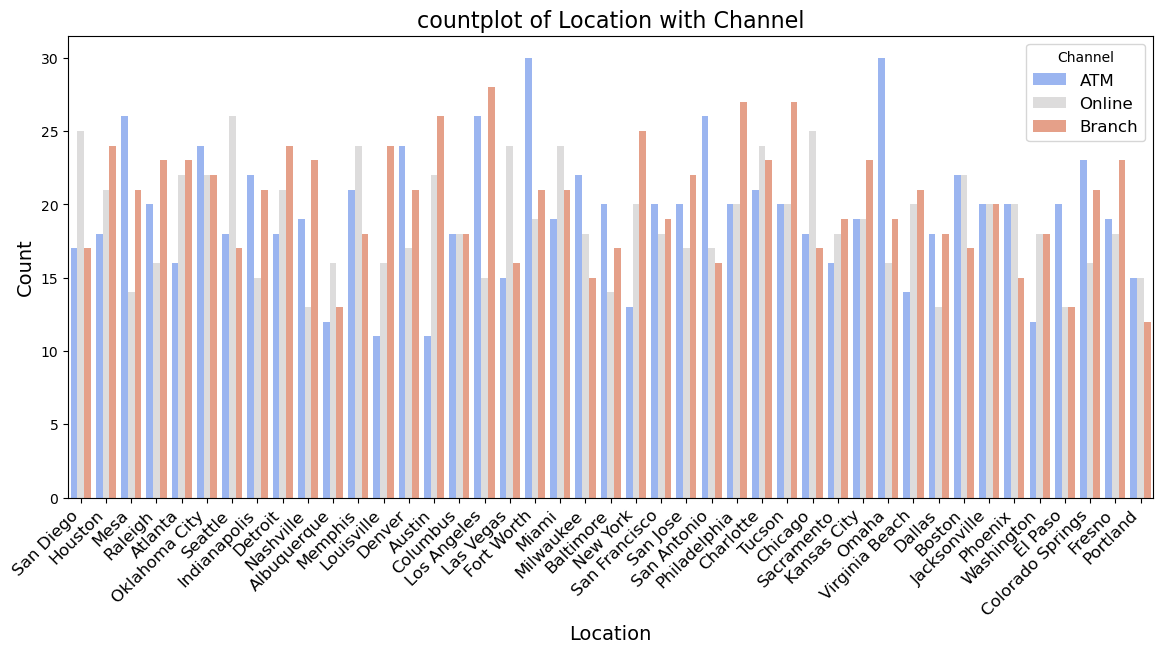

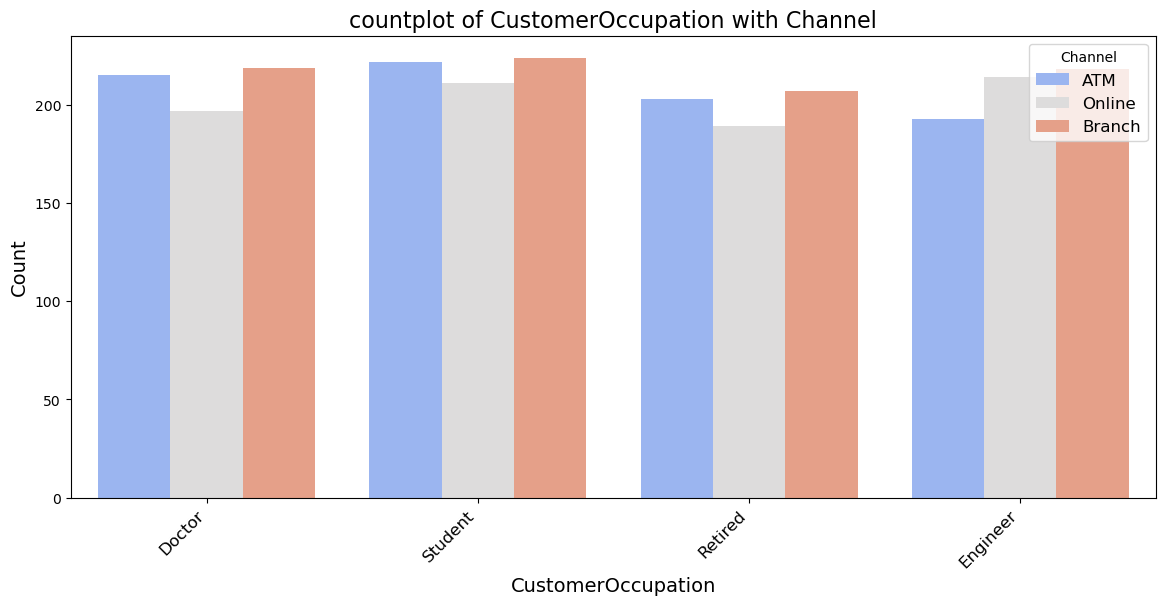

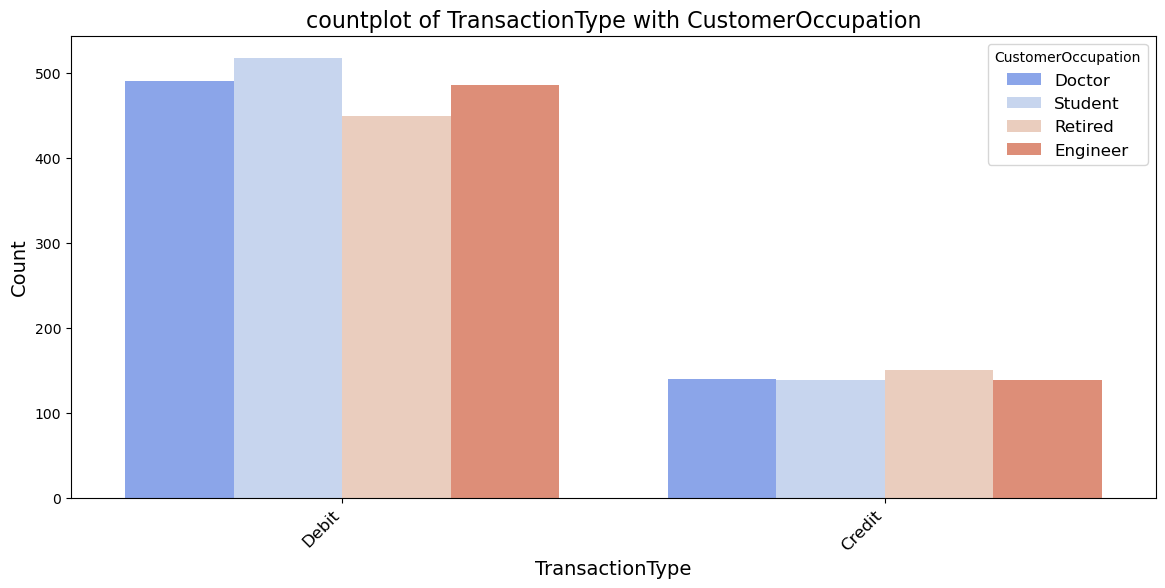

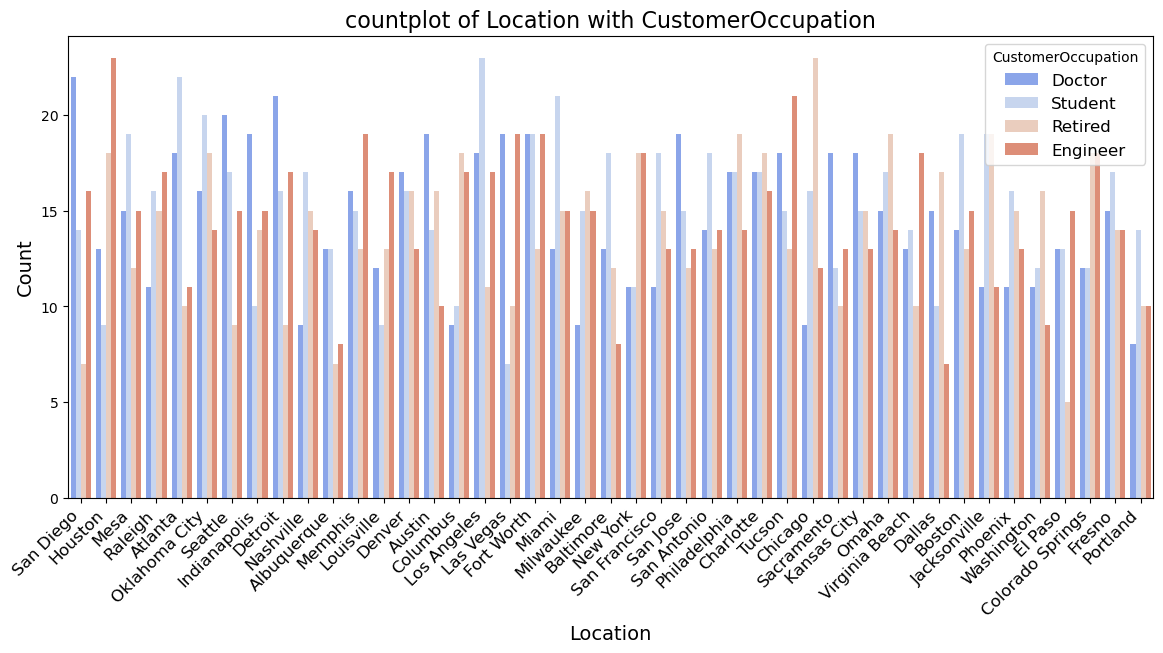

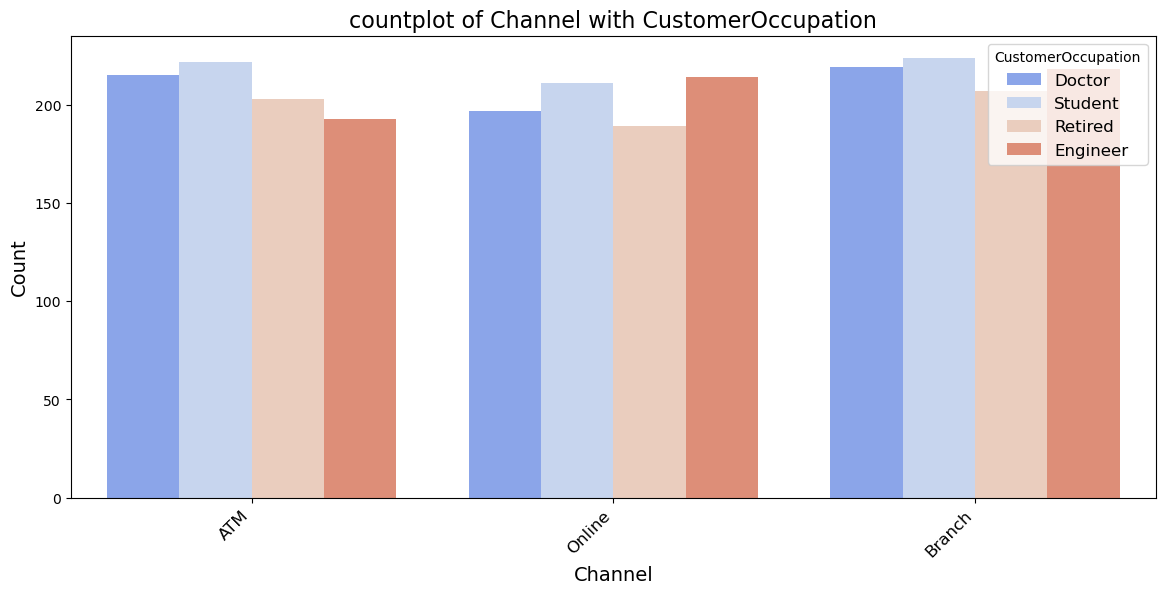

In [56]:
# countplot with hue fot categorical vs categorical

for cate1 in categ_cols:
    for cate2 in categ_cols:
        if cate1 != cate2: # avoid self-comparison
            plt.figure(figsize=(14, 6))
            sns.countplot(x=cate2, hue=cate1, data=df, palette="coolwarm")
            plt.title(f"countplot of {cate2} with {cate1}", fontsize=16)
            plt.xlabel(cate2, fontsize=14)
            plt.ylabel("Count", fontsize=14)
            plt.xticks(rotation=45, fontsize=12, ha="right")
            plt.legend(title=cate1, fontsize=12)
            plt.show()

Multivariate Analysis

In [57]:
# Multivariate analysis deals with the analysis of multiple variables simultaneously. Essentially, it's about understanding
# the relationships and patterns within dataset that contain more than two variables

In [59]:
warnings.filterwarnings("ignore", category=FutureWarning)

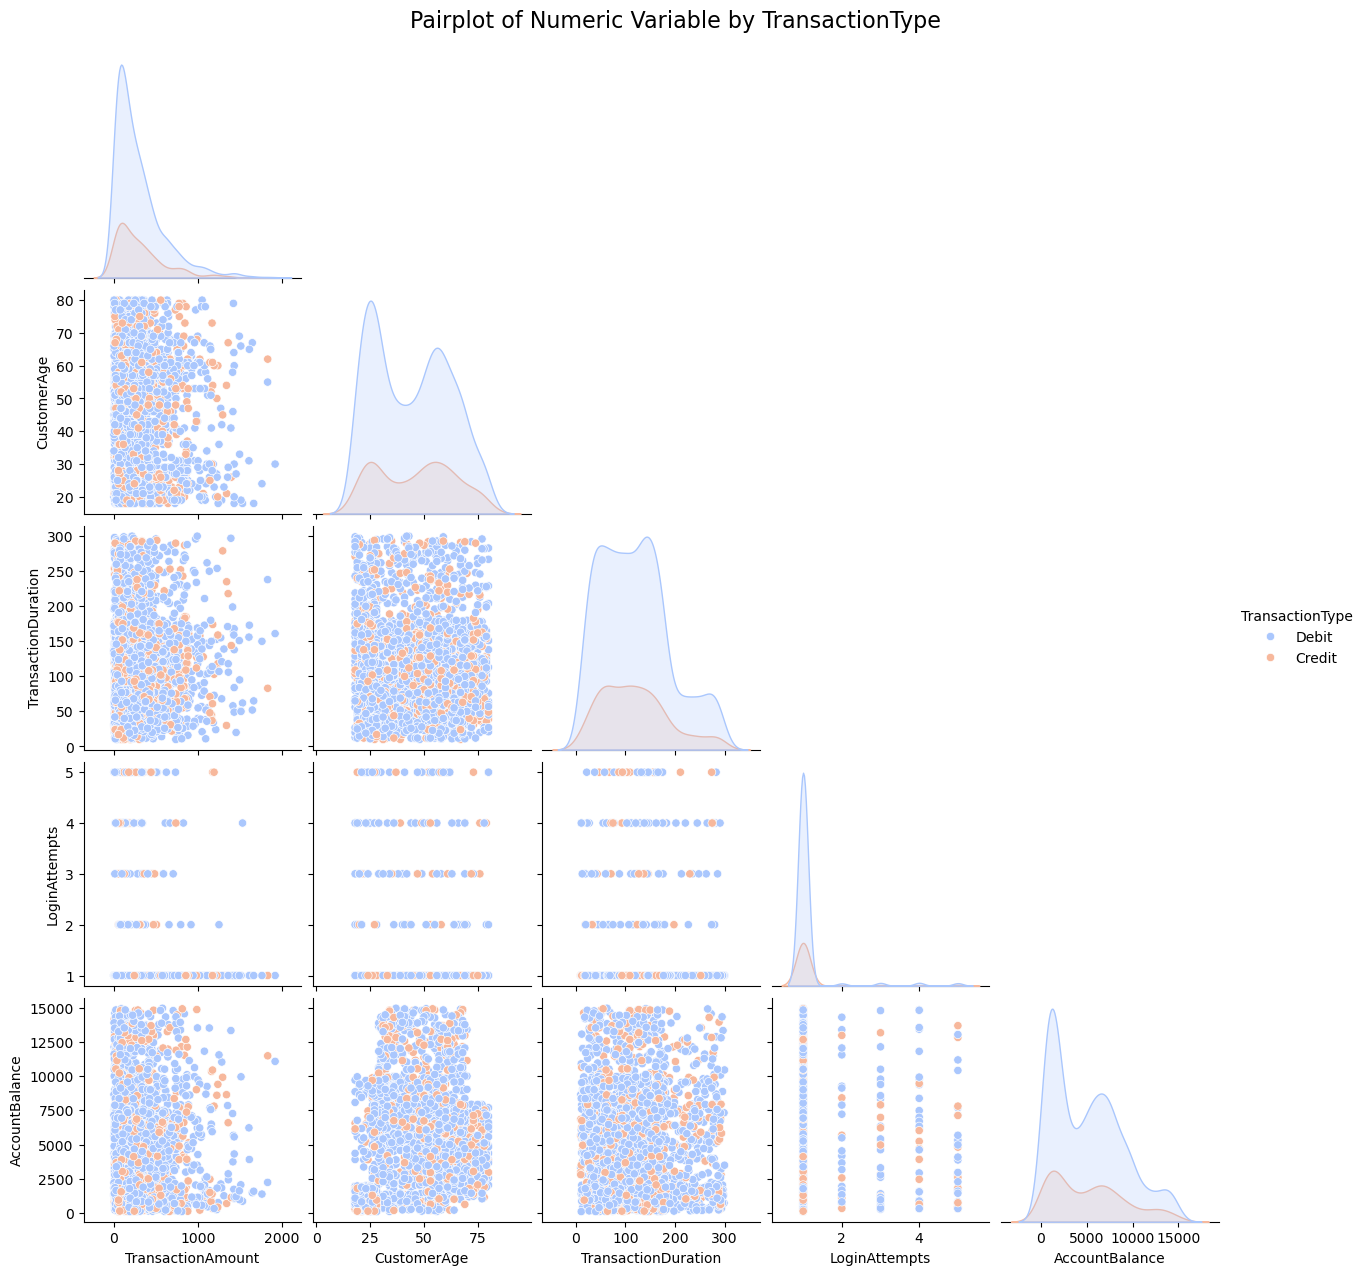

In [61]:
sns.pairplot(df, vars=numeric_cols, hue="TransactionType", palette="coolwarm", corner= True, diag_kind="kde")
plt.suptitle("Pairplot of Numeric Variable by TransactionType", fontsize=16, y=1.02)
plt.show()

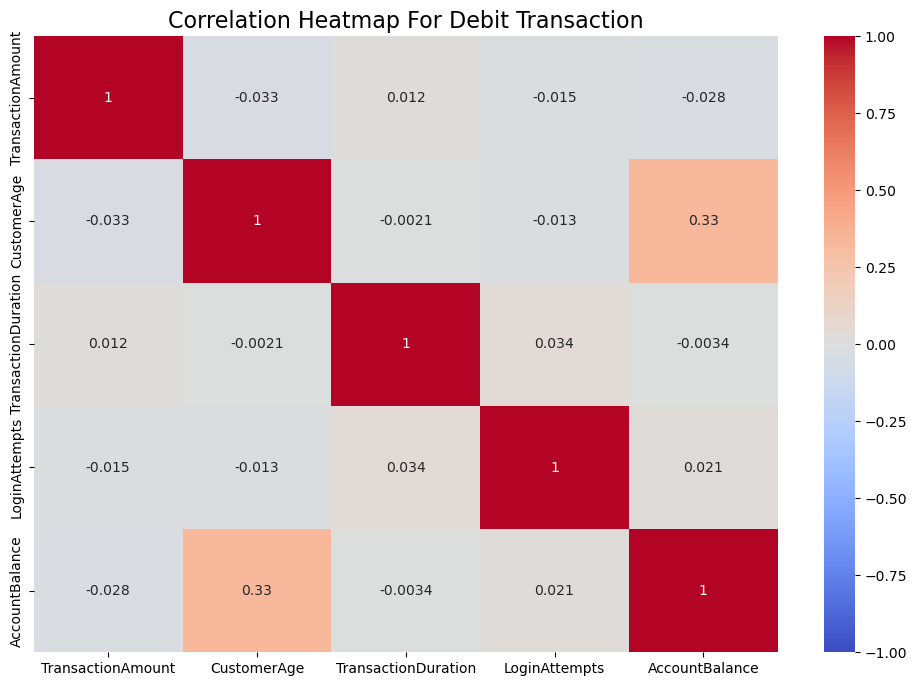

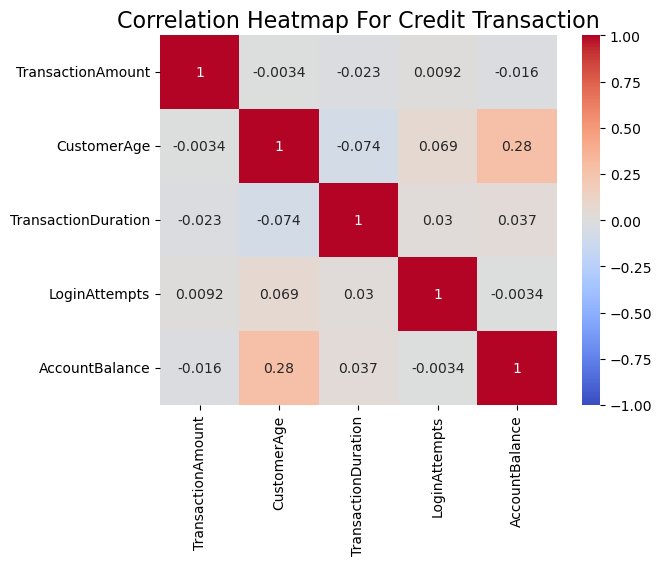

In [63]:
# Heatmap of Numeric Correlations grouped by a categorical variable
plt.figure(figsize=(12, 8))
for transaction_type in df["TransactionType"].unique():
    subset = df[df["TransactionType"]==transaction_type]
    plt.title(f"Correlation Heatmap For {transaction_type} Transaction", fontsize=16)
    sns.heatmap(subset[numeric_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.show()

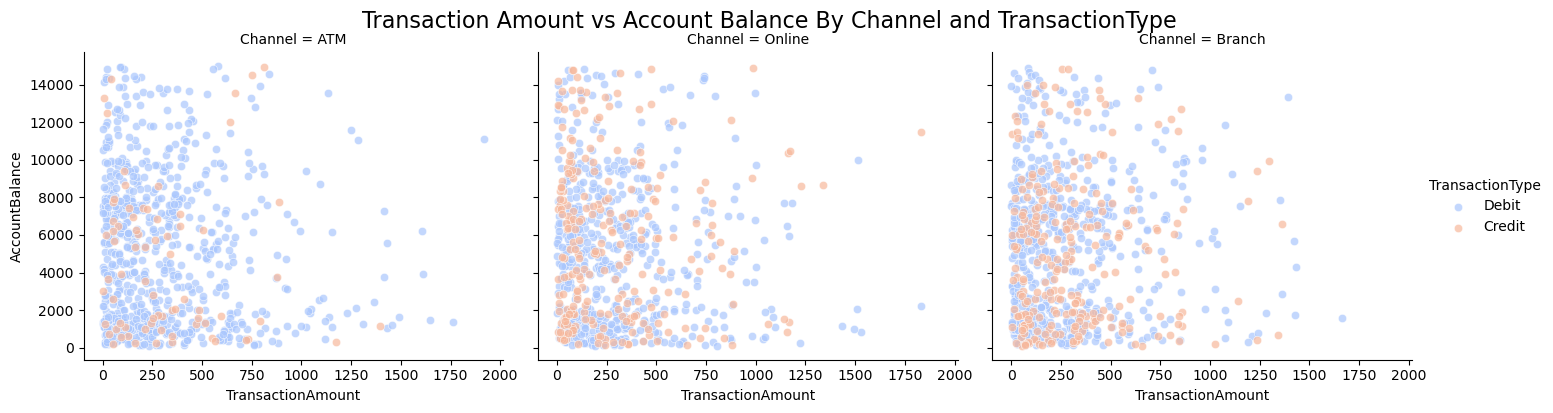

In [64]:
# FacetGrid: Scatterplot of Transaction Amount vs Account Balance By Channel
g = sns.FacetGrid(df, col="Channel", hue="TransactionType", palette="coolwarm", height=4, aspect=1.2)
g.map(sns.scatterplot, "TransactionAmount", "AccountBalance", alpha=0.7)
g.add_legend()
g.fig.suptitle("Transaction Amount vs Account Balance By Channel and TransactionType", fontsize=16, y=1.02)
plt.show()

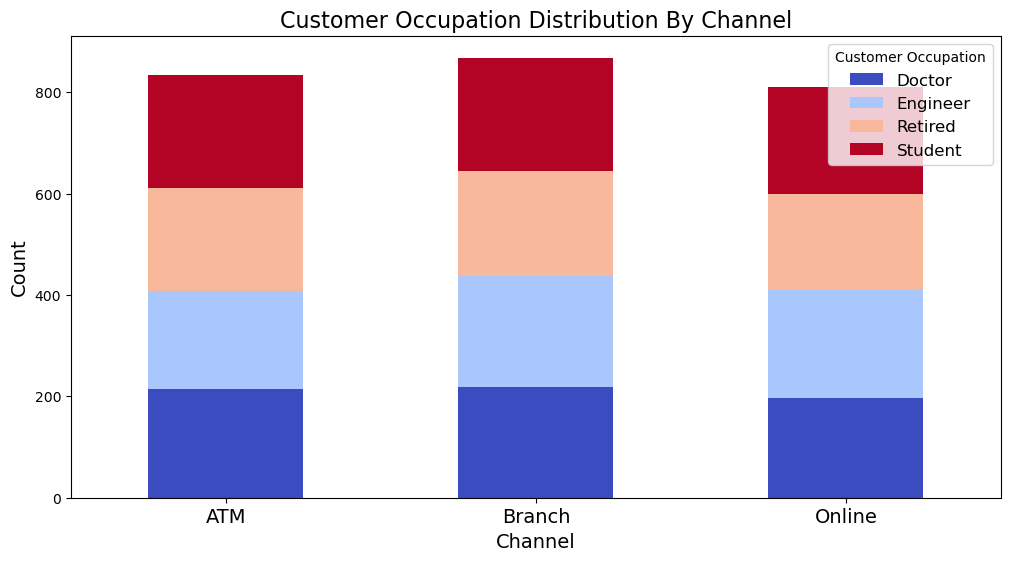

In [66]:
# Stacked Bar Chart: Customer Occupation Distribution By Channel
Occup_channel = df.groupby(["Channel", "CustomerOccupation"]).size().unstack()
Occup_channel.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="coolwarm")
plt.title("Customer Occupation Distribution By Channel", fontsize=16)
plt.xlabel("Channel", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=0, fontsize=14)
plt.legend(title="Customer Occupation", fontsize=12)
plt.show()

In [140]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"] , format= "mixed" )
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"], format= "mixed")
df["TimeSinceLastTransaction"] = (df["TransactionDate"] - df["PreviousTransactionDate"]).dt.total_seconds()

In [141]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSinceLastTransaction
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:00,-49477140.0
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:00,-42823500.0
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:00,-41694660.0
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:00,-47403420.0
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:00,-33228900.0


Preprocessing 

In [142]:
# list out numeric and categorical columns 

numeric_cols = ["TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance", "CustomerAge", "TimeSinceLastTransaction"]

categ_cols = ["TransactionType", "Location", "Channel", "CustomerOccupation"]

In [146]:
# Normalize numeric columns
scaler = StandardScaler()
numeric_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)

In [147]:
# One-hot encode categorical columns 
encoder = OneHotEncoder(sparse_output=False, drop="first") # Avoid dummy variabletrap
categorical_encoder = pd.DataFrame(encoder.fit_transform(df[categ_cols]), columns=encoder.get_feature_names_out(categ_cols))

In [148]:
proc_data = pd.concat([numeric_scaled, categorical_encoder], axis=1)

In [150]:
print(df[numeric_cols].describe())

       TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
count        2512.000000  2512.000000          2512.000000    2512.000000   
mean          297.593778    44.673965           119.643312       1.124602   
std           291.946243    17.792198            69.963757       0.602662   
min             0.260000    18.000000            10.000000       1.000000   
25%            81.885000    27.000000            63.000000       1.000000   
50%           211.140000    45.000000           112.500000       1.000000   
75%           414.527500    59.000000           161.000000       1.000000   
max          1919.110000    80.000000           300.000000       5.000000   

       AccountBalance  CustomerAge  TimeSinceLastTransaction  
count     2512.000000  2512.000000              2.512000e+03  
mean      5114.302966    44.673965             -4.211863e+07  
std       3900.942499    17.792198              9.191205e+06  
min        101.250000    18.000000             -5.8032

In [151]:
# Initialize fraud column
df["Fraud"] = False

Isolation Forest

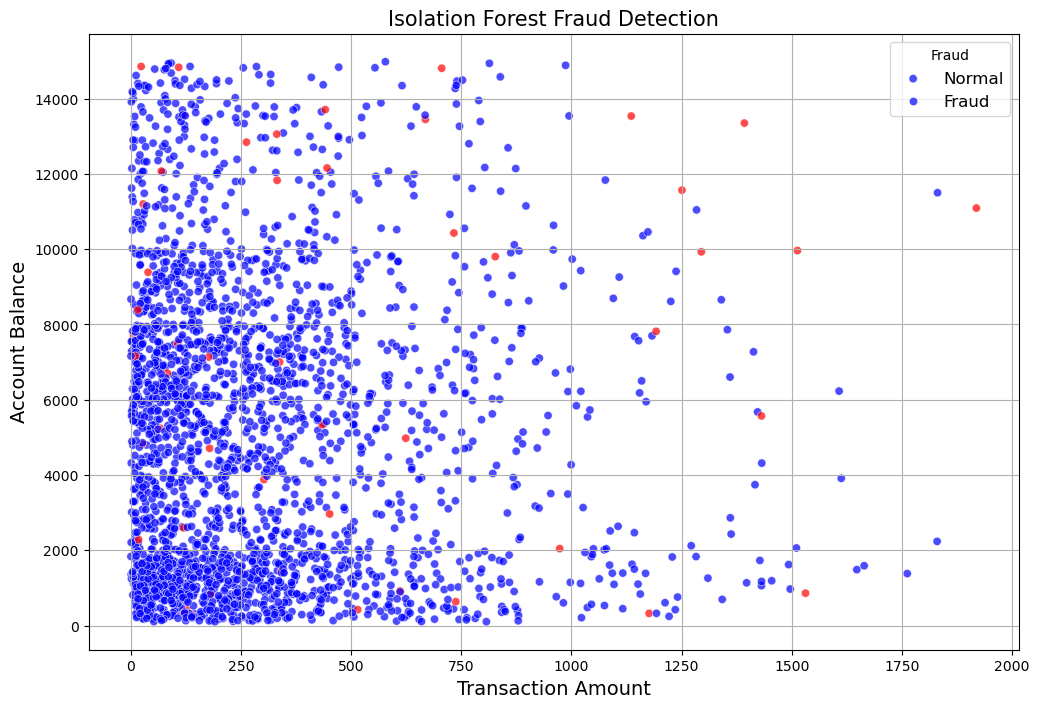

In [153]:
# Isolation forest helps highlights anomalous transactions uxing tree-based partitioning
warnings.filterwarnings("ignore", category=FutureWarning)

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.02, random_state=42) #2% expected anomalies

iso_forest.fit(numeric_scaled)

# predict anomalies
df["IsoForest_Score"] = iso_forest.decision_function(numeric_scaled)
df["IsoForest_Fraud"] = iso_forest.predict(numeric_scaled) == -1 # mark anomalies (-1) as fraud

# Extract fraudulent transaction
iso_fraud_points = df[df["IsoForest_Fraud"]]

# Summary fraudulent forest results
total_iso_fraud_points = df["IsoForest_Fraud"].sum()
iso_fraud_points_summary = iso_fraud_points[["TransactionAmount", "TransactionDuration", "AccountBalance", "IsoForest_Fraud"]]

# Adding True values to fraud column
df["Fraud"] |= df["IsoForest_Fraud"] 

# Scatterplot to visualize fraud points
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x = df["TransactionAmount"],
    y = df["AccountBalance"],
    hue = df["IsoForest_Fraud"],
    palette = {True: "red", False: "blue"},
    alpha = 0.7

)

plt.title("Isolation Forest Fraud Detection", fontsize = 15)
plt.xlabel("Transaction Amount", fontsize = 14)
plt.ylabel("Account Balance", fontsize = 14)
plt.legend(title = "Fraud", labels=["Normal", "Fraud"], fontsize=12)
plt.grid(True)
plt.show()

In [154]:
# outputs values
total_iso_fraud_points, iso_fraud_points_summary.head(), iso_fraud_points_summary.shape

(51,
      TransactionAmount  TransactionDuration  AccountBalance  IsoForest_Fraud
 146             973.39                  296         2042.22             True
 147             514.95                  142          421.93             True
 231             705.60                  124        14804.70             True
 266              66.90                  129         5238.71             True
 274            1176.28                  174          323.69             True,
 (51, 4))

In [157]:
# save fraudulent transaction noticed by isolation forest
fraud_output_path = "/kaggle/working/zscore_fraud_transactions.csv"
iso_fraud_points.to_csv(fraud_output_path, index=False)

OSError: Cannot save file into a non-existent directory: '\kaggle\working'

In [158]:
# Define relevant columns for our regression

input_features = ["TransactionAmount", "TransactionDuration", "LoginAttempts", "AccountBalance", "CustomerAge","TimeSinceLastTransaction"]
target = "Fraud"



In [159]:
# prepare the data
X = df[input_features]
y = df[target]



In [160]:
# standardize the input_features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [167]:
# split the dataset into training and testing sets 

test_size = 0.3
seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [168]:
# Train the logistic Regression model

log_regression = LogisticRegression(random_state=seed)

log_regression.fit(X_train, y_train)

# predict fraud on the test set
y_pred = log_regression.predict(X_test) 

# Evaluate fraud preformance 
print("classification Report:")
print(classification_report(y_test, y_pred))

print("accuracy score:")
print(accuracy_score(y_test,y_pred))


print("roc auc score:")
print(roc_auc_score(y_test, y_pred))

classification Report:
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       738
        True       0.00      0.00      0.00        16

    accuracy                           0.98       754
   macro avg       0.49      0.50      0.49       754
weighted avg       0.96      0.98      0.97       754

accuracy score:
0.9787798408488063
roc auc score:
0.5


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

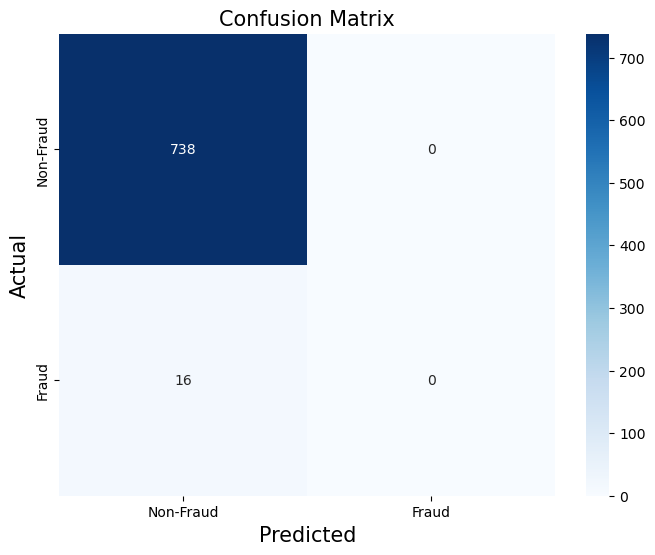

In [169]:
# Confusion Matrix
confus_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confus_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud","Fraud"])
plt.title("Confusion Matrix", fontsize=15)
plt.xlabel("Predicted", fontsize=15)
plt.ylabel("Actual", fontsize=15)
plt.show()

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


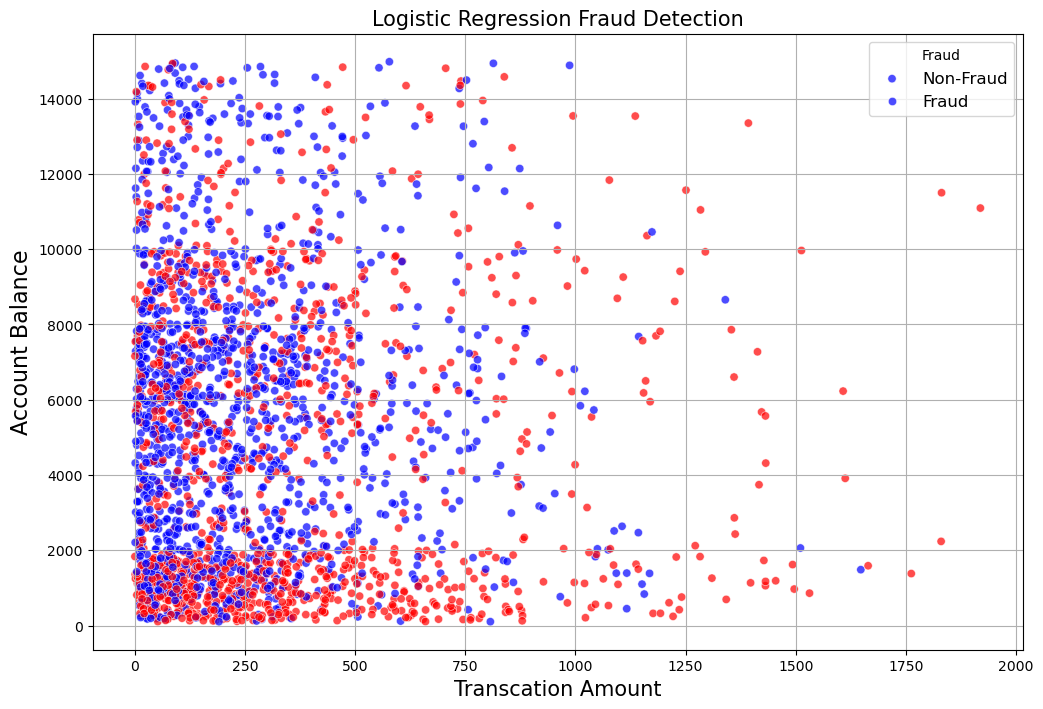

In [171]:
# add predictions to the dataset 
df["LogReg_Fraud"] = log_regression.predict(X_scaled)
df["Fraud"] |= df["LogReg_Fraud"]

#Visualize fraud vs non-fraud transactions
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df["TransactionAmount"],
    y = df["AccountBalance"],
    hue = df["LogReg_Fraud"],
    palette={1: "red", 0: "blue"},
    alpha = 0.7
)
plt.title("Logistic Regression Fraud Detection", fontsize=15)
plt.xlabel("Transcation Amount", fontsize = 15)
plt.ylabel("Account Balance", fontsize=16)
plt.legend(title="Fraud", labels=["Non-Fraud", "Fraud"], fontsize=12)
plt.grid(True)
plt.show()

In [210]:
def plotRocAuc(xgb_model,X, y):

    probabilities = log_regression.predict_proba(X)
    probabilities = probabilities[:, 1]

    fpr, tpr, thresholds = roc_curve(y, probabilities)

    plt.plot([0,1], [0,1], linestyle = "--")

    plt.plot(fpr, tpr, marker = ".")
    plt.text(0.75, 0.25, "AUC: " + str(round(roc_auc_score(y, probabilities),2)))

    plt.show()

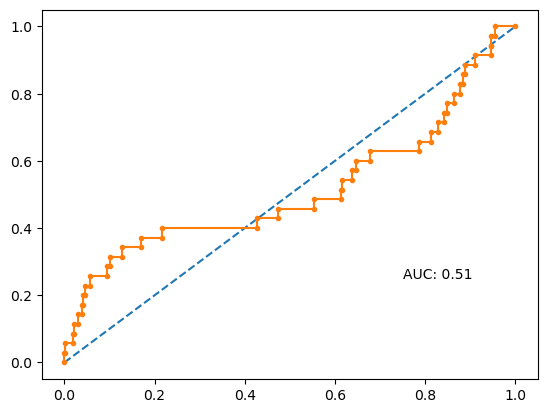

In [211]:
plotRocAuc(log_regression, X_train, y_train)

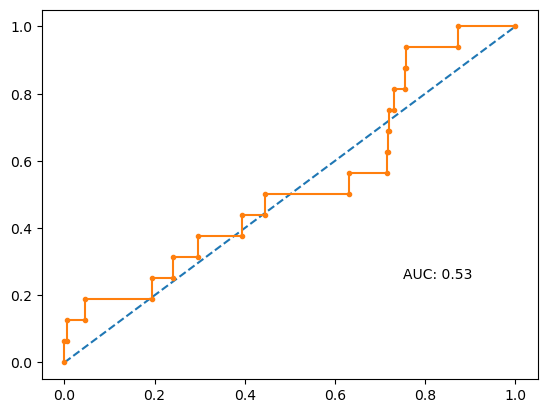

In [212]:
plotRocAuc(log_regression, X_test, y_test)

In [172]:
 from xgboost import XGBClassifier


Training Accuracy: 0.9994
Testing Accuracy: 0.9881
classification report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       738
        True       0.89      0.50      0.64        16

    accuracy                           0.99       754
   macro avg       0.94      0.75      0.82       754
weighted avg       0.99      0.99      0.99       754



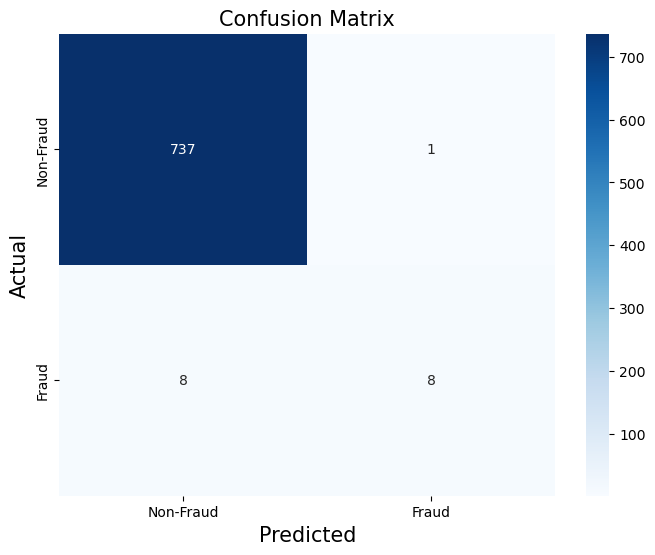

In [179]:
xgb_model = XGBClassifier(n_estimators = 70, max_depth=7, learning_rate=0.1, random_state=42)

xgb_model.fit(X_train, y_train)

y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

# Evaluate fraud on the test set
print("classification report:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
confusi_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confusi_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud", "Fraud"])
plt.title("Confusion Matrix", fontsize=15)
plt.xlabel("Predicted", fontsize=15)
plt.ylabel("Actual", fontsize= 15)
plt.show()


In [208]:
def plotRocAuc(xgb_model,X, y):

    probabilities = xgb_model.predict_proba(X)
    probabilities = probabilities[:, 1]

    fpr, tpr, thresholds = roc_curve(y, probabilities)

    plt.plot([0,1], [0,1], linestyle = "--")

    plt.plot(fpr, tpr, marker = ".")
    plt.text(0.75, 0.25, "AUC: " + str(round(roc_auc_score(y, probabilities),2)))

    plt.show()

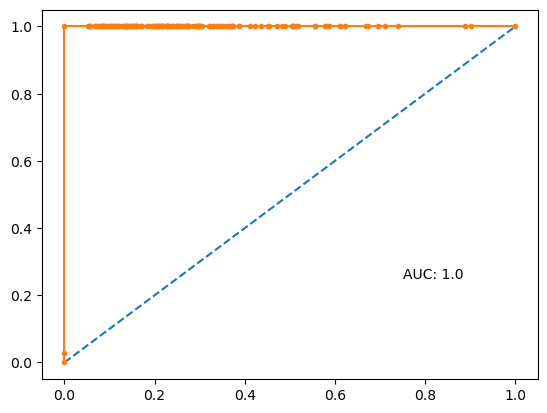

In [209]:
plotRocAuc(xgb_model, X_train, y_train)

In [206]:
def plotRocAuc(xgb_model,X, y):

    probabilities = xgb_model.predict_proba(X)
    probabilities = probabilities[:, 1]

    fpr, tpr, thresholds = roc_curve(y, probabilities)

    plt.plot([0,1], [0,1], linestyle = "--")

    plt.plot(fpr, tpr, marker = ".")
    plt.text(0.75, 0.25, "AUC: " + str(round(roc_auc_score(y, probabilities),2)))

    plt.show()

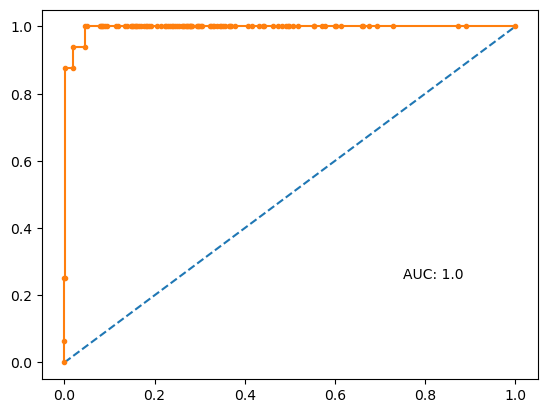

In [207]:
plotRocAuc(xgb_model, X_test, y_test)

K-Means

In [ ]:
numeric_cols1 = ["TransactionAmount", "CustomerAge", "TransactionDuration", "LoginAttempts", "AccountBalance", "CustomerAge"]

# Standardize numeric columns for k-means cluster
scaler = StandardScaler()
numeric_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols1]), columns=numeric_cols1)

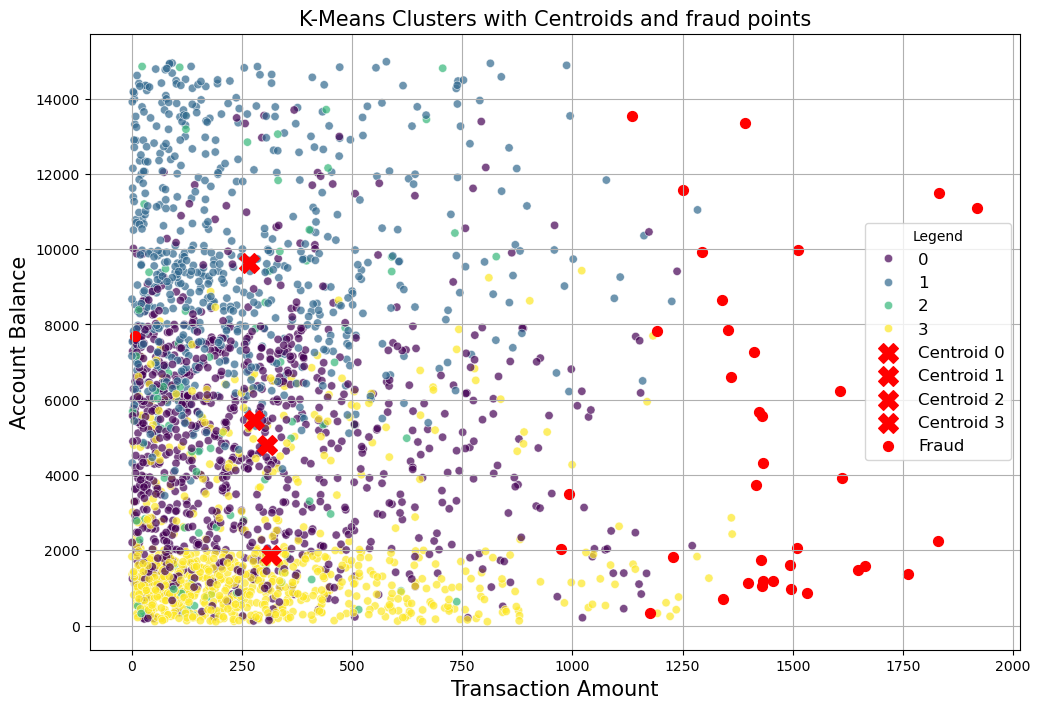

In [220]:
# perform k-mean clustering
kmeans = KMeans(n_init="auto") # Futureproofing 

kmeans.fit(numeric_scaled)
n_clusters = 4 
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_lab = kmeans.fit_predict(numeric_scaled)
df["KMeans_Cluster"] = kmeans_lab

# Calculate distance from centroids

centroids = kmeans.cluster_centers_
distances = np.linalg.norm(numeric_scaled.values - centroids[kmeans_lab], axis=1)
df["KMeans_Distance"] = distances

# Set threshold: mean + 3 * standard deviation 
threshold = distances.mean() + 3 * distances.std()
df["KMeans_Fraud"] = distances > threshold

# summary of flagged anomalies
fraud_summary = df["KMeans_Fraud"].value_counts()
threshold, fraud_summary, df[["TransactionAmount", "KMeans_Distance", "KMeans_Fraud"]].head()

# Calculate centroids and scale them back to the original feature space
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Add a fraud detection logic (using distance from centroids)
distances = np.linalg.norm(numeric_scaled - centroids_scaled[kmeans_lab], axis=1)
threshold = distances.mean() + 3 * distances.std()
df["Fraud"] = distances > threshold
df["KMeans Distance"] = distances

# scatterplot for two features with clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df["TransactionAmount"],
    y=df["AccountBalance"],
    hue=df["KMeans_Cluster"],
    palette="viridis",
    alpha = 0.7,
    legend="full"
)

# overlay centroids on the scatterplot
for i, centroid in enumerate(centroids_original):
    plt.scatter(
        centroid[numeric_cols1.index("TransactionAmount")],
        centroid[numeric_cols1.index("AccountBalance")],
        color = "red",
        marker= "X",
        s = 200,
        label = f"Centroid {i}"

    )

# highlight fraud points
fraud_points = df[df["Fraud"]]
plt.scatter(
    fraud_points["TransactionAmount"],
    fraud_points["AccountBalance"],
    color = "red",
    marker="o",
    s=50,
    label="Fraud"
)

plt.title("K-Means Clusters with Centroids and fraud points", fontsize=15)
plt.xlabel("Transaction Amount", fontsize= 15)
plt.ylabel("Account Balance", fontsize =15)
plt.legend(title = "Legend", fontsize=12)
plt.grid(True)
plt.show()